In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import os
import tabix
from scipy.stats import pearsonr, spearmanr
import gzip

In [2]:
gtex_colors = {
  "Adipose-Subcutaneous": {
    "tissue_abbrv": "ADPSBQ", 
    "tissue_color_hex": "FFA54F", 
    "tissue_color_rgb": "255,165,79"
  }, 
  "Adipose-Visceral_Omentum": {
    "tissue_abbrv": "ADPVSC", 
    "tissue_color_hex": "EE9A00", 
    "tissue_color_rgb": "238,154,0"
  }, 
  "AdrenalGland": {
    "tissue_abbrv": "ADRNLG", 
    "tissue_color_hex": "8FBC8F", 
    "tissue_color_rgb": "143,188,143"
  }, 
  "Artery-Aorta": {
    "tissue_abbrv": "ARTAORT", 
    "tissue_color_hex": "8B1C62", 
    "tissue_color_rgb": "139,28,98"
  }, 
  "Artery-Coronary": {
    "tissue_abbrv": "ARTCRN", 
    "tissue_color_hex": "EE6A50", 
    "tissue_color_rgb": "238,106,80"
  }, 
  "Artery-Femoral": {
    "tissue_abbrv": "ARTFMR", 
    "tissue_color_hex": "FF4500", 
    "tissue_color_rgb": "255,69,0"
  }, 
  "Artery-Tibial": {
    "tissue_abbrv": "ARTTBL", 
    "tissue_color_hex": "FF0000", 
    "tissue_color_rgb": "255,0,0"
  }, 
  "Bladder": {
    "tissue_abbrv": "BLDDER", 
    "tissue_color_hex": "CDB79E", 
    "tissue_color_rgb": "205,183,158"
  }, 
  "Brain-Amygdala": {
    "tissue_abbrv": "BRNAMY", 
    "tissue_color_hex": "EEEE00", 
    "tissue_color_rgb": "238,238,0"
  }, 
  "Brain-Anteriorcingulatecortex_BA24": {
    "tissue_abbrv": "BRNACC", 
    "tissue_color_hex": "EEEE00", 
    "tissue_color_rgb": "238,238,0"
  }, 
  "Brain-Caudate_basalganglia": {
    "tissue_abbrv": "BRNCDT", 
    "tissue_color_hex": "EEEE00", 
    "tissue_color_rgb": "238,238,0"
  }, 
  "Brain-CerebellarHemisphere": {
    "tissue_abbrv": "BRNCHB", 
    "tissue_color_hex": "EEEE00", 
    "tissue_color_rgb": "238,238,0"
  }, 
  "Brain-Cerebellum": {
    "tissue_abbrv": "BRNCHA", 
    "tissue_color_hex": "EEEE00", 
    "tissue_color_rgb": "238,238,0"
  }, 
  "Brain-Cortex": {
    "tissue_abbrv": "BRNCTXA", 
    "tissue_color_hex": "EEEE00", 
    "tissue_color_rgb": "238,238,0"
  }, 
  "Brain-FrontalCortex_BA9": {
    "tissue_abbrv": "BRNCTXB", 
    "tissue_color_hex": "EEEE00", 
    "tissue_color_rgb": "238,238,0"
  }, 
  "Brain-Hippocampus": {
    "tissue_abbrv": "BRNHPP", 
    "tissue_color_hex": "EEEE00", 
    "tissue_color_rgb": "238,238,0"
  }, 
  "Brain-Hypothalamus": {
    "tissue_abbrv": "BRNHPT", 
    "tissue_color_hex": "EEEE00", 
    "tissue_color_rgb": "238,238,0"
  }, 
  "Brain-Nucleusaccumbens_basalganglia": {
    "tissue_abbrv": "BRNNCC", 
    "tissue_color_hex": "EEEE00", 
    "tissue_color_rgb": "238,238,0"
  }, 
  "Brain-Putamen_basalganglia": {
    "tissue_abbrv": "BRNPTM", 
    "tissue_color_hex": "EEEE00", 
    "tissue_color_rgb": "238,238,0"
  }, 
  "Brain-Spinalcord_cervicalc-1": {
    "tissue_abbrv": "BRNSPC", 
    "tissue_color_hex": "EEEE00", 
    "tissue_color_rgb": "238,238,0"
  }, 
  "Brain-Substantianigra": {
    "tissue_abbrv": "BRNSNG", 
    "tissue_color_hex": "EEEE00", 
    "tissue_color_rgb": "238,238,0"
  }, 
  "Breast-MammaryTissue": {
    "tissue_abbrv": "BREAST", 
    "tissue_color_hex": "00CDCD", 
    "tissue_color_rgb": "0,205,205"
  }, 
  "Cells-EBV-transformedlymphocytes": {
    "tissue_abbrv": "LCL", 
    "tissue_color_hex": "EE82EE", 
    "tissue_color_rgb": "238,130,238"
  }, 
  "Cells-Culturedfibroblasts": {
    "tissue_abbrv": "FIBRBLS", 
    "tissue_color_hex": "9AC0CD", 
    "tissue_color_rgb": "154,192,205"
  }, 
  "Cervix-Ectocervix": {
    "tissue_abbrv": "CVXECT", 
    "tissue_color_hex": "EED5D2", 
    "tissue_color_rgb": "238,213,210"
  }, 
  "Cervix-Endocervix": {
    "tissue_abbrv": "CVSEND", 
    "tissue_color_hex": "EED5D2", 
    "tissue_color_rgb": "238,213,210"
  }, 
  "Colon-Sigmoid": {
    "tissue_abbrv": "CLNSGM", 
    "tissue_color_hex": "CDB79E", 
    "tissue_color_rgb": "205,183,158"
  }, 
  "Colon-Transverse": {
    "tissue_abbrv": "CLNTRN", 
    "tissue_color_hex": "EEC591", 
    "tissue_color_rgb": "238,197,145"
  }, 
  "Esophagus-GastroesophagealJunction": {
    "tissue_abbrv": "ESPGEJ", 
    "tissue_color_hex": "8B7355", 
    "tissue_color_rgb": "139,115,85"
  }, 
  "Esophagus-Mucosa": {
    "tissue_abbrv": "ESPMCS", 
    "tissue_color_hex": "8B7355", 
    "tissue_color_rgb": "139,115,85"
  }, 
  "Esophagus-Muscularis": {
    "tissue_abbrv": "ESPMSL", 
    "tissue_color_hex": "CDAA7D", 
    "tissue_color_rgb": "205,170,125"
  }, 
  "FallopianTube": {
    "tissue_abbrv": "FLLPNT", 
    "tissue_color_hex": "EED5D2", 
    "tissue_color_rgb": "238,213,210"
  }, 
  "Heart-AtrialAppendage": {
    "tissue_abbrv": "HRTAA", 
    "tissue_color_hex": "B452CD", 
    "tissue_color_rgb": "180,82,205"
  }, 
  "Heart-LeftVentricle": {
    "tissue_abbrv": "HRTLV", 
    "tissue_color_hex": "7A378B", 
    "tissue_color_rgb": "122,55,139"
  }, 
  "Kidney-Cortex": {
    "tissue_abbrv": "KDNCTX", 
    "tissue_color_hex": "CDB79E", 
    "tissue_color_rgb": "205,183,158"
  }, 
  "Kidney-Medulla": {
    "tissue_abbrv": "KDNMDL", 
    "tissue_color_hex": "CDB79E", 
    "tissue_color_rgb": "205,183,158"
  }, 
  "Liver": {
    "tissue_abbrv": "LIVER", 
    "tissue_color_hex": "CDB79E", 
    "tissue_color_rgb": "205,183,158"
  }, 
  "Lung": {
    "tissue_abbrv": "LUNG", 
    "tissue_color_hex": "9ACD32", 
    "tissue_color_rgb": "154,205,50"
  }, 
  "MinorSalivaryGland": {
    "tissue_abbrv": "SLVRYG", 
    "tissue_color_hex": "CDB79E", 
    "tissue_color_rgb": "205,183,158"
  }, 
  "Muscle-Skeletal": {
    "tissue_abbrv": "MSCLSK", 
    "tissue_color_hex": "7A67EE", 
    "tissue_color_rgb": "122,103,238"
  }, 
  "Nerve-Tibial": {
    "tissue_abbrv": "NERVET", 
    "tissue_color_hex": "FFD700", 
    "tissue_color_rgb": "255,215,0"
  }, 
  "Ovary": {
    "tissue_abbrv": "OVARY", 
    "tissue_color_hex": "FFB6C1", 
    "tissue_color_rgb": "255,182,193"
  }, 
  "Pancreas": {
    "tissue_abbrv": "PNCREAS", 
    "tissue_color_hex": "CD9B1D", 
    "tissue_color_rgb": "205,155,29"
  }, 
  "Pituitary": {
    "tissue_abbrv": "PTTARY", 
    "tissue_color_hex": "B4EEB4", 
    "tissue_color_rgb": "180,238,180"
  }, 
  "Prostate": {
    "tissue_abbrv": "PRSTTE", 
    "tissue_color_hex": "D9D9D9", 
    "tissue_color_rgb": "217,217,217"
  }, 
  "Skin-NotSunExposed_Suprapubic": {
    "tissue_abbrv": "SKINNS", 
    "tissue_color_hex": "3A5FCD", 
    "tissue_color_rgb": "58,95,205"
  }, 
  "Skin-SunExposed_Lowerleg": {
    "tissue_abbrv": "SKINS", 
    "tissue_color_hex": "1E90FF", 
    "tissue_color_rgb": "30,144,255"
  }, 
  "SmallIntestine-TerminalIleum": {
    "tissue_abbrv": "SNTTRM", 
    "tissue_color_hex": "CDB79E", 
    "tissue_color_rgb": "205,183,158"
  }, 
  "Spleen": {
    "tissue_abbrv": "SPLEEN", 
    "tissue_color_hex": "CDB79E", 
    "tissue_color_rgb": "205,183,158"
  }, 
  "Stomach": {
    "tissue_abbrv": "STMACH", 
    "tissue_color_hex": "FFD39B", 
    "tissue_color_rgb": "255,211,155"
  }, 
  "Testis": {
    "tissue_abbrv": "TESTIS", 
    "tissue_color_hex": "A6A6A6", 
    "tissue_color_rgb": "166,166,166"
  }, 
  "Thyroid": {
    "tissue_abbrv": "THYROID", 
    "tissue_color_hex": "008B45", 
    "tissue_color_rgb": "0,139,69"
  }, 
  "Uterus": {
    "tissue_abbrv": "UTERUS", 
    "tissue_color_hex": "EED5D2", 
    "tissue_color_rgb": "238,213,210"
  }, 
  "Vagina": {
    "tissue_abbrv": "VAGINA", 
    "tissue_color_hex": "EED5D2", 
    "tissue_color_rgb": "238,213,210"
  }, 
  "WholeBlood": {
    "tissue_abbrv": "WHLBLD", 
    "tissue_color_hex": "FF00FF", 
    "tissue_color_rgb": "255,0,255"
  }
}

In [3]:
def run_tabix_on_nom(nom_file, coords, transform_to_df = True):
    chrom, start, end = coords.split(':')
    start = int(start)
    end = int(end)
    
    tb = tabix.open(nom_file)
    nom = tb.query(chrom, start, end)
    
    
    
    if transform_to_df:
        columns = ['#phe_id', 'phe_chr', 'phe_from', 'phe_to', 'phe_strd', 'n_var_in_cis', 'dist_phe_var', 'var_id', 
                   'var_chr', 'var_from', 'var_to', 'nom_pval', 'r_squared', 'slope', 'slope_se', 'best_hit']
        
#         columns = ['#phe_id', 'phe_chr', 'phe_from', 'phe_to', 'phe_strd', 'n_var_in_cis', 'dist_phe_var', 'var_id', 
#                    'var_chr', 'var_from', 'var_to', 'nom_pval', 'r_squared', 'slope', 'slope_se', 'best_hit']

        nom_bed = []#pd.DataFrame()
        nom_bed_cols = []
        
        # Iterate over queried junctions and store them in the DataFrame
        for idx, record in enumerate(nom):
            nom_bed.append(pd.Series(record))
            nom_bed_cols.append(f'record{str(idx)}')
            # junctions_bed[f'record{str(idx)}'] = record
        # print(record)
        # print(junctions_bed)
        nom_bed = pd.concat(nom_bed, axis=1)
        nom_bed.columns = nom_bed_cols
        nom_bed = nom_bed.T
        nom_bed.columns = columns
        nom_bed['#phe_id'] = nom_bed['#phe_id'].apply(lambda x: x.split('.')[0])
        return nom_bed
    
    return nom

In [4]:
def get_expression_effect(tissue, perm_qtl):
    var_id = perm_qtl.var_id
    chrom = perm_qtl.var_chr
    start = str(int(perm_qtl.var_from) - 1)
    
    end = str(int(perm_qtl.var_to) + 1)
    
    coords = f'{chrom}:{start}:{end}'
    
    gene = perm_qtl.gene_id.split('.')[0]
            
    nom_file = f'../code/results/eqtl/GTEx/{tissue}/cis_100000/nom/{chrom}.txt.gz'
    nom_df = run_tabix_on_nom(nom_file, coords, transform_to_df=True)
    nom_df = nom_df.loc[(nom_df['#phe_id'] == gene) & (nom_df['var_id'] == var_id)]

    return nom_df

In [5]:
def get_intron_list(tissue):
    intron_list = []
    cluster_list = []
    median_count_list = []
    with gzip.open(
        f'/project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/{tissue}/leafcutter_perind_numers.counts.noise_by_intron.gz'
    ) as fh:
        fh.readline()
        for line in fh:
            line = line.decode().rstrip().split(' ')
            intron_list.append(line[0])
            cluster_list.append(line[0].split(':')[0] + ':' + line[0].split(':')[-2])
            median_counts = int(np.median([int(y) for y in line[1:]]))
            median_count_list.append(median_counts)

    intron_median_counts = pd.DataFrame()
    intron_median_counts['phenotype_id'] = intron_list
    intron_median_counts['cluster'] = cluster_list
    intron_median_counts['median_counts'] = median_count_list
    intron_median_counts['intron'] = intron_median_counts.phenotype_id.apply(lambda x: ':'.join(x.split(':')[:-1]))
    
    return intron_median_counts

In [6]:
def get_perm_counts(tissue):
#     results/sqtl/GTEx/Ovary/cis_100000/perm/PermutationPass.Qval.txt.gz
    perm = pd.read_csv(f'../code/results/sqtl/GTEx/{tissue}/cis_100000/perm/PermutationPass.Qval.txt.gz', sep='\t')
    intron_median_counts = get_intron_list(tissue)
    perm_counts = pd.merge(perm, intron_median_counts, right_on=['phenotype_id', 'intron', 'cluster'], 
         left_on=['phe_id', 'intron', 'cluster'])
    counts_per_cluster = perm_counts.groupby('cluster').median_counts.sum().reset_index()
    counts_per_cluster.columns = ['cluster', 'cluster_counts']

    counts_per_gene = perm_counts.groupby('gene_id').median_counts.sum().reset_index()
    counts_per_gene.columns = ['gene_id', 'gene_counts']
    
    perm_counts = pd.merge(perm_counts, counts_per_cluster, left_on='cluster', right_on='cluster')
    perm_counts = pd.merge(perm_counts, counts_per_gene, left_on='gene_id', right_on='gene_id')
    perm_counts['intron_psi'] = perm_counts.median_counts/(perm_counts.cluster_counts+1e-10)
    perm_counts['cluster_psi'] = perm_counts.cluster_counts/(perm_counts.gene_counts+1e-10)
    UP_per_cluster = perm_counts.groupby('cluster').itype.apply(lambda x: (x == 'UP').sum()).reset_index()
    UP_per_cluster.columns = ['cluster', 'UP_juncs']
    perm_counts = pd.merge(perm_counts, UP_per_cluster, left_on='cluster', right_on='cluster')
    
    return perm_counts

In [7]:
perm = pd.read_csv(f'../code/results/sqtl/GTEx/Testis/cis_100000/perm/PermutationPass.Qval.txt.gz', sep='\t')

In [8]:
len(perm.cluster.unique())#loc[perm.q <= 0.1]#.adj_beta_pval.max()

34961

In [9]:
# perm_counts = get_perm_counts('Testis')
# perm_counts = pd.merge(perm_counts, counts_per_cluster, left_on='cluster', right_on='cluster')
# perm_counts = pd.merge(perm_counts, counts_per_gene, left_on='gene_id', right_on='gene_id')
# perm_counts['intron_psi'] = perm_counts.median_counts/(perm_counts.cluster_counts+1e-10)
# perm_counts['cluster_psi'] = perm_counts.cluster_counts/(perm_counts.gene_counts+1e-10)
# UP_per_cluster = perm_counts.groupby('cluster').itype.apply(lambda x: (x == 'UP').sum()).reset_index()
# UP_per_cluster.columns = ['cluster', 'UP_juncs']
# perm_counts = pd.merge(perm_counts, UP_per_cluster, left_on='cluster', right_on='cluster')

In [11]:
# perm_counts.cluster.unique()

In [7]:
def get_sqtl_expression_effects(perm_counts, tissue, ctype='PR,UP', itype='UP', qmax = 1e-2, clu_psi_min=0.1):
    sqtl_slopes = []
    eqtl_slopes = []
    eqtl_pvals = []

    perm_select = perm_counts.loc[(perm_counts.ctype == ctype) & (perm_counts.itype == itype) & (perm_counts.q <= qmax) & (perm_counts.cluster_psi >= clu_psi_min)]
    # idx = perm_counts.loc[(perm_counts.ctype == 'PR,UP') & (perm_counts.itype == 'UP') & (perm_counts.q <= 1e-2)].groupby('gene_id').median_counts.idxmax()
    # perm_select = perm_counts.loc[idx]

#     print(perm_select.columns)
    for idx, row in perm_select.iterrows():
        try:
            eqtl_df = get_expression_effect(tissue, row)
            if eqtl_df.shape[0] > 0:
                eqtl_effect = float(eqtl_df.iloc[0].slope)#/float(eqtl_df.iloc[0].slope_se)
                sqtl_slopes.append(float(row.slope))#/float(row.slope_se))
                eqtl_slopes.append(float(eqtl_effect))
                eqtl_pvals.append(float(eqtl_df.iloc[0].nom_pval))
        except:
            continue
        
    return sqtl_slopes, eqtl_slopes, eqtl_pvals

In [8]:
def get_usqtl_expression_effects(perm_counts, tissue, qmax = 1e-2, clu_psi_min=0.1):
    sqtl_slopes = []
    eqtl_slopes = []
    eqtl_pvals = []
    
    ctype_UP = ['PR,UP', 'NE,PR', 'NE,PR,UP', 'IN,NE,PR', 'IN,PR', 'IN,NE,PR,UP', 'IN,PR', 'IN,PR,UP']
    itype_UP = ['UP']

    perm_select = perm_counts.loc[(perm_counts.ctype.isin(ctype_UP)) & (perm_counts.itype.isin(itype_UP)) & (perm_counts.q <= qmax) & (perm_counts.cluster_psi >= clu_psi_min)]
    # idx = perm_counts.loc[(perm_counts.ctype == 'PR,UP') & (perm_counts.itype == 'UP') & (perm_counts.q <= 1e-2)].groupby('gene_id').median_counts.idxmax()
    # perm_select = perm_counts.loc[idx]

#     print(perm_select.columns)
    for idx, row in perm_select.iterrows():
        try:
            eqtl_df = get_expression_effect(tissue, row)
            if eqtl_df.shape[0] > 0:
                eqtl_effect = float(eqtl_df.iloc[0].slope)/float(eqtl_df.iloc[0].slope_se)
                sqtl_slopes.append(float(row.slope)/float(row.slope_se))
                eqtl_slopes.append(float(eqtl_effect))
                eqtl_pvals.append(float(eqtl_df.iloc[0].nom_pval))
        except:
            continue
        
    return sqtl_slopes, eqtl_slopes, eqtl_pvals

In [14]:
# s_slope, e_slope, e_pvals = get_usqtl_expression_effects(perm_counts, 'Testis', qmax = 1e-10)

In [15]:
# s_slope, e_slope, e_pvals = get_sqtl_expression_effects(perm_counts, 'Testis', ctype='PR,UP', itype='UP', qmax = 1e-2, clu_psi_min=0.5)

In [16]:
# spearmanr(s_slope, e_slope)

In [17]:
# perm_counts.loc[(perm_counts.q <= 0.1)].ctype.value_counts()

In [18]:
# perm_counts = get_perm_counts('Testis')

In [19]:
# perm_counts.cluster

In [20]:
# len(perm_counts.loc[(perm_counts.q<=0.1) & (perm_counts.ctype=='PR')].gene_id.unique())

In [21]:
# perm['intron_'] = perm.intron.apply(lambda x: ':'.join(x.split(':')[:-1]))

In [22]:
# len(perm.groupby('cluster').intron_.sum().unique())

In [9]:
def get_tissue_sQTLs_cluster_list(tissue):
    perm_counts = get_perm_counts(tissue)
    perm_counts['intron_'] = perm_counts.intron.apply(lambda x: ':'.join(x.split(':')[:-1]))
    tissue_dict = {
        'PR':list(perm_counts.loc[(perm_counts.q<=0.1) & (perm_counts.ctype=='PR')].groupby('cluster').intron_.sum().unique()),
        'UP':list(perm_counts.loc[(perm_counts.q<=0.1) & (perm_counts.ctype=='PR,UP')].groupby('cluster').intron_.sum().unique()),
        'Other':list(perm_counts.loc[(perm_counts.q<=0.1) & (perm_counts.ctype!='PR') & (perm_counts.ctype!='PR,UP')].groupby('cluster').intron_.sum().unique())
    }
    return(tissue_dict)

In [24]:
from tqdm import tqdm
sqtl_dict = {}
tissues = sorted(os.listdir('../code/results/sqtl/GTEx/'))
sqtl_stats = {}
for tissue in tqdm(tissues, position=0, leave=True):
    tissue_dict = get_tissue_sQTLs_cluster_list(tissue)
    sqtl_dict.update({tissue:tissue_dict})

  0%|                                                                                                                                                                   | 0/49 [00:02<?, ?it/s]


KeyboardInterrupt: 

In [44]:
pr_clu = []
up_clu = []
for tissue in sqtl_dict.keys():
    pr_clu += list(sqtl_dict[tissue]['PR'])
    up_clu += list(sqtl_dict[tissue]['UP'])
    
    

In [45]:
len(set(pr_clu))

32334

In [49]:
len(set(up_clu))

16816

In [47]:
len(up_clu)

51664

In [25]:
def get_tissue_sQTLs_gene_counts(tissue):
    perm_counts = get_perm_counts(tissue)
    tissue_dict = {
        'PR':list(perm_counts.loc[(perm_counts.q<=0.1) & (perm_counts.ctype=='PR')].gene_id.unique()),
        'UP':list(perm_counts.loc[(perm_counts.q<=0.1) & (perm_counts.ctype=='PR,UP')].gene_id.unique()),
        'Other':list(perm_counts.loc[(perm_counts.q<=0.1) & (perm_counts.ctype!='PR') & (perm_counts.ctype!='PR,UP')].gene_id.unique())
    }
    return(tissue_dict)

In [24]:
from tqdm import tqdm
sqtl_dict = {}
tissues = sorted(os.listdir('../code/results/sqtl/GTEx/'))
sqtl_stats = {}
for tissue in tqdm(tissues, position=0, leave=True):
    tissue_dict = get_tissue_sQTLs_gene_counts(tissue)
    sqtl_dict.update({tissue:tissue_dict})

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 49/49 [10:36<00:00, 12.99s/it]


In [29]:
pr_genes = []
up_genes = []
for tissue in sqtl_dict.keys():
    pr_genes += list(sqtl_dict[tissue]['PR'])
    up_genes += list(sqtl_dict[tissue]['UP'])

In [30]:
len(set(pr_genes))

9387

In [31]:
len(set(up_genes))

5107

In [32]:
pr_genes = []
up_genes = []
for tissue in sqtl_dict.keys():
    pr_genes.append(len(sqtl_dict[tissue]['PR']))
    up_genes.append(len(sqtl_dict[tissue]['UP']))

In [34]:
np.median(pr_genes)

np.float64(1525.0)

In [35]:
np.median(up_genes)

np.float64(880.0)

In [26]:
def get_tissue_sQTLs(tissue):
    perm_counts = get_perm_counts(tissue)
    tissue_dict = {
        'PR':((perm_counts.q<=0.1) & (perm_counts.ctype=='PR')).sum(),
        'UP':((perm_counts.q<=0.1) & (perm_counts.ctype=='PR,UP')).sum(),
        'Other':((perm_counts.q<=0.1) & (perm_counts.ctype!='PR') & (perm_counts.ctype != 'PR,UP')).sum()
    }
    return(tissue_dict)

In [61]:
from tqdm import tqdm
sqtl_dict = {}
tissues = sorted(os.listdir('../code/results/sqtl/GTEx/'))
sqtl_stats = {}
for tissue in tqdm(tissues, position=0, leave=True):
    tissue_dict = get_tissue_sQTLs(tissue)
    sqtl_dict.update({tissue:tissue_dict})

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 49/49 [11:01<00:00, 13.51s/it]


In [62]:
qtl_dataframe = pd.DataFrame(sqtl_dict).T

In [63]:
qtl_dataframe['total'] = qtl_dataframe.sum(axis=1)

In [28]:
# qtl_dataframe.to_csv('Total_sQTLs.tsv.gz', sep='\t', header=True, index=True)
qtl_dataframe = pd.read_csv('../code/analysis_files/Total_sQTLs.tsv.gz', sep='\t', index_col=0)

In [30]:
# Sort dataframe by total in descending order
sorted_tissues = qtl_dataframe.sort_values(by="total", ascending=False).index

c_list = []
for tissue in sorted_tissues:
    c = '#' + gtex_colors[tissue]['tissue_color_hex']
    c_list.append(c)

In [31]:
qtl_dataframe.PR.median()

np.float64(3082.0)

In [32]:
qtl_dataframe.UP.median()

np.float64(1800.0)

In [33]:
n = 0
for tissue in qtl_dataframe.index:
    perm = pd.read_csv(f'../code/results/sqtl/GTEx/{tissue}/cis_100000/perm/PermutationPass.Qval.txt.gz', sep='\t')
    n+= (perm.dof1+2).iloc[0]
    
print(n)

15201


In [34]:
sorted_tissues_renamed = ['Testis', 'Thyroid', 'Nerve - Tibial', 'Adipose - Subcutaneous',
       'Skin - Sun exposed (lower leg)', 'Artery - Tibial',
       'Cells - Cultured fibroblasts', 'Lung', 'Skin - Not sun exposed (suprapubic)',
       'Muscle - Skeletal', 'Adipose - Visceral (omentum)', 'Esophagus - Muscularis',
       'Esophagus - Mucosa', 'Breast - Mammary tissue', 'Artery - Aorta',
       'Colon - Transverse', 'Esophagus - Gastroesophageal junction', 'Whole blood',
       'Colon - Sigmoid', 'Heart - Atrial appendage', 'Pituitary', 'Stomach',
       'Spleen', 'Brain - Cerebellum', 'Heart - Left ventricle', 'Adrenal gland',
       'Prostate', 'Pancreas', 'Brain - Cerebellar hemisphere',
       'Cells - EBV-transformed lymphocytes', 'Artery - Coronary', 'Brain - Cortex',
       'Ovary', 'Small intestine - Terminal ileum',
       'Brain - Nucleus accumbens (basal ganglia)', 'Brain - Caudate (basal ganglia)',
       'Minor salivary gland', 'Brain - Frontal cortex (BA9)', 'Uterus', 'Vagina',
       'Liver', 'Brain - Hypothalamus', 'Brain - Putamen (basal ganglia)',
       'Brain - Anterior cingulate cortex (BA24)', 'Brain - Hippocampus',
       'Brain - Spinalcord (cervical c-1)', 'Brain - Amygdala',
       'Brain - Substantia nigra', 'Kidney - Cortex']

In [35]:
qtl_dataframe.UP.max()

np.int64(4589)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 49/49 [00:22<00:00,  2.21it/s]


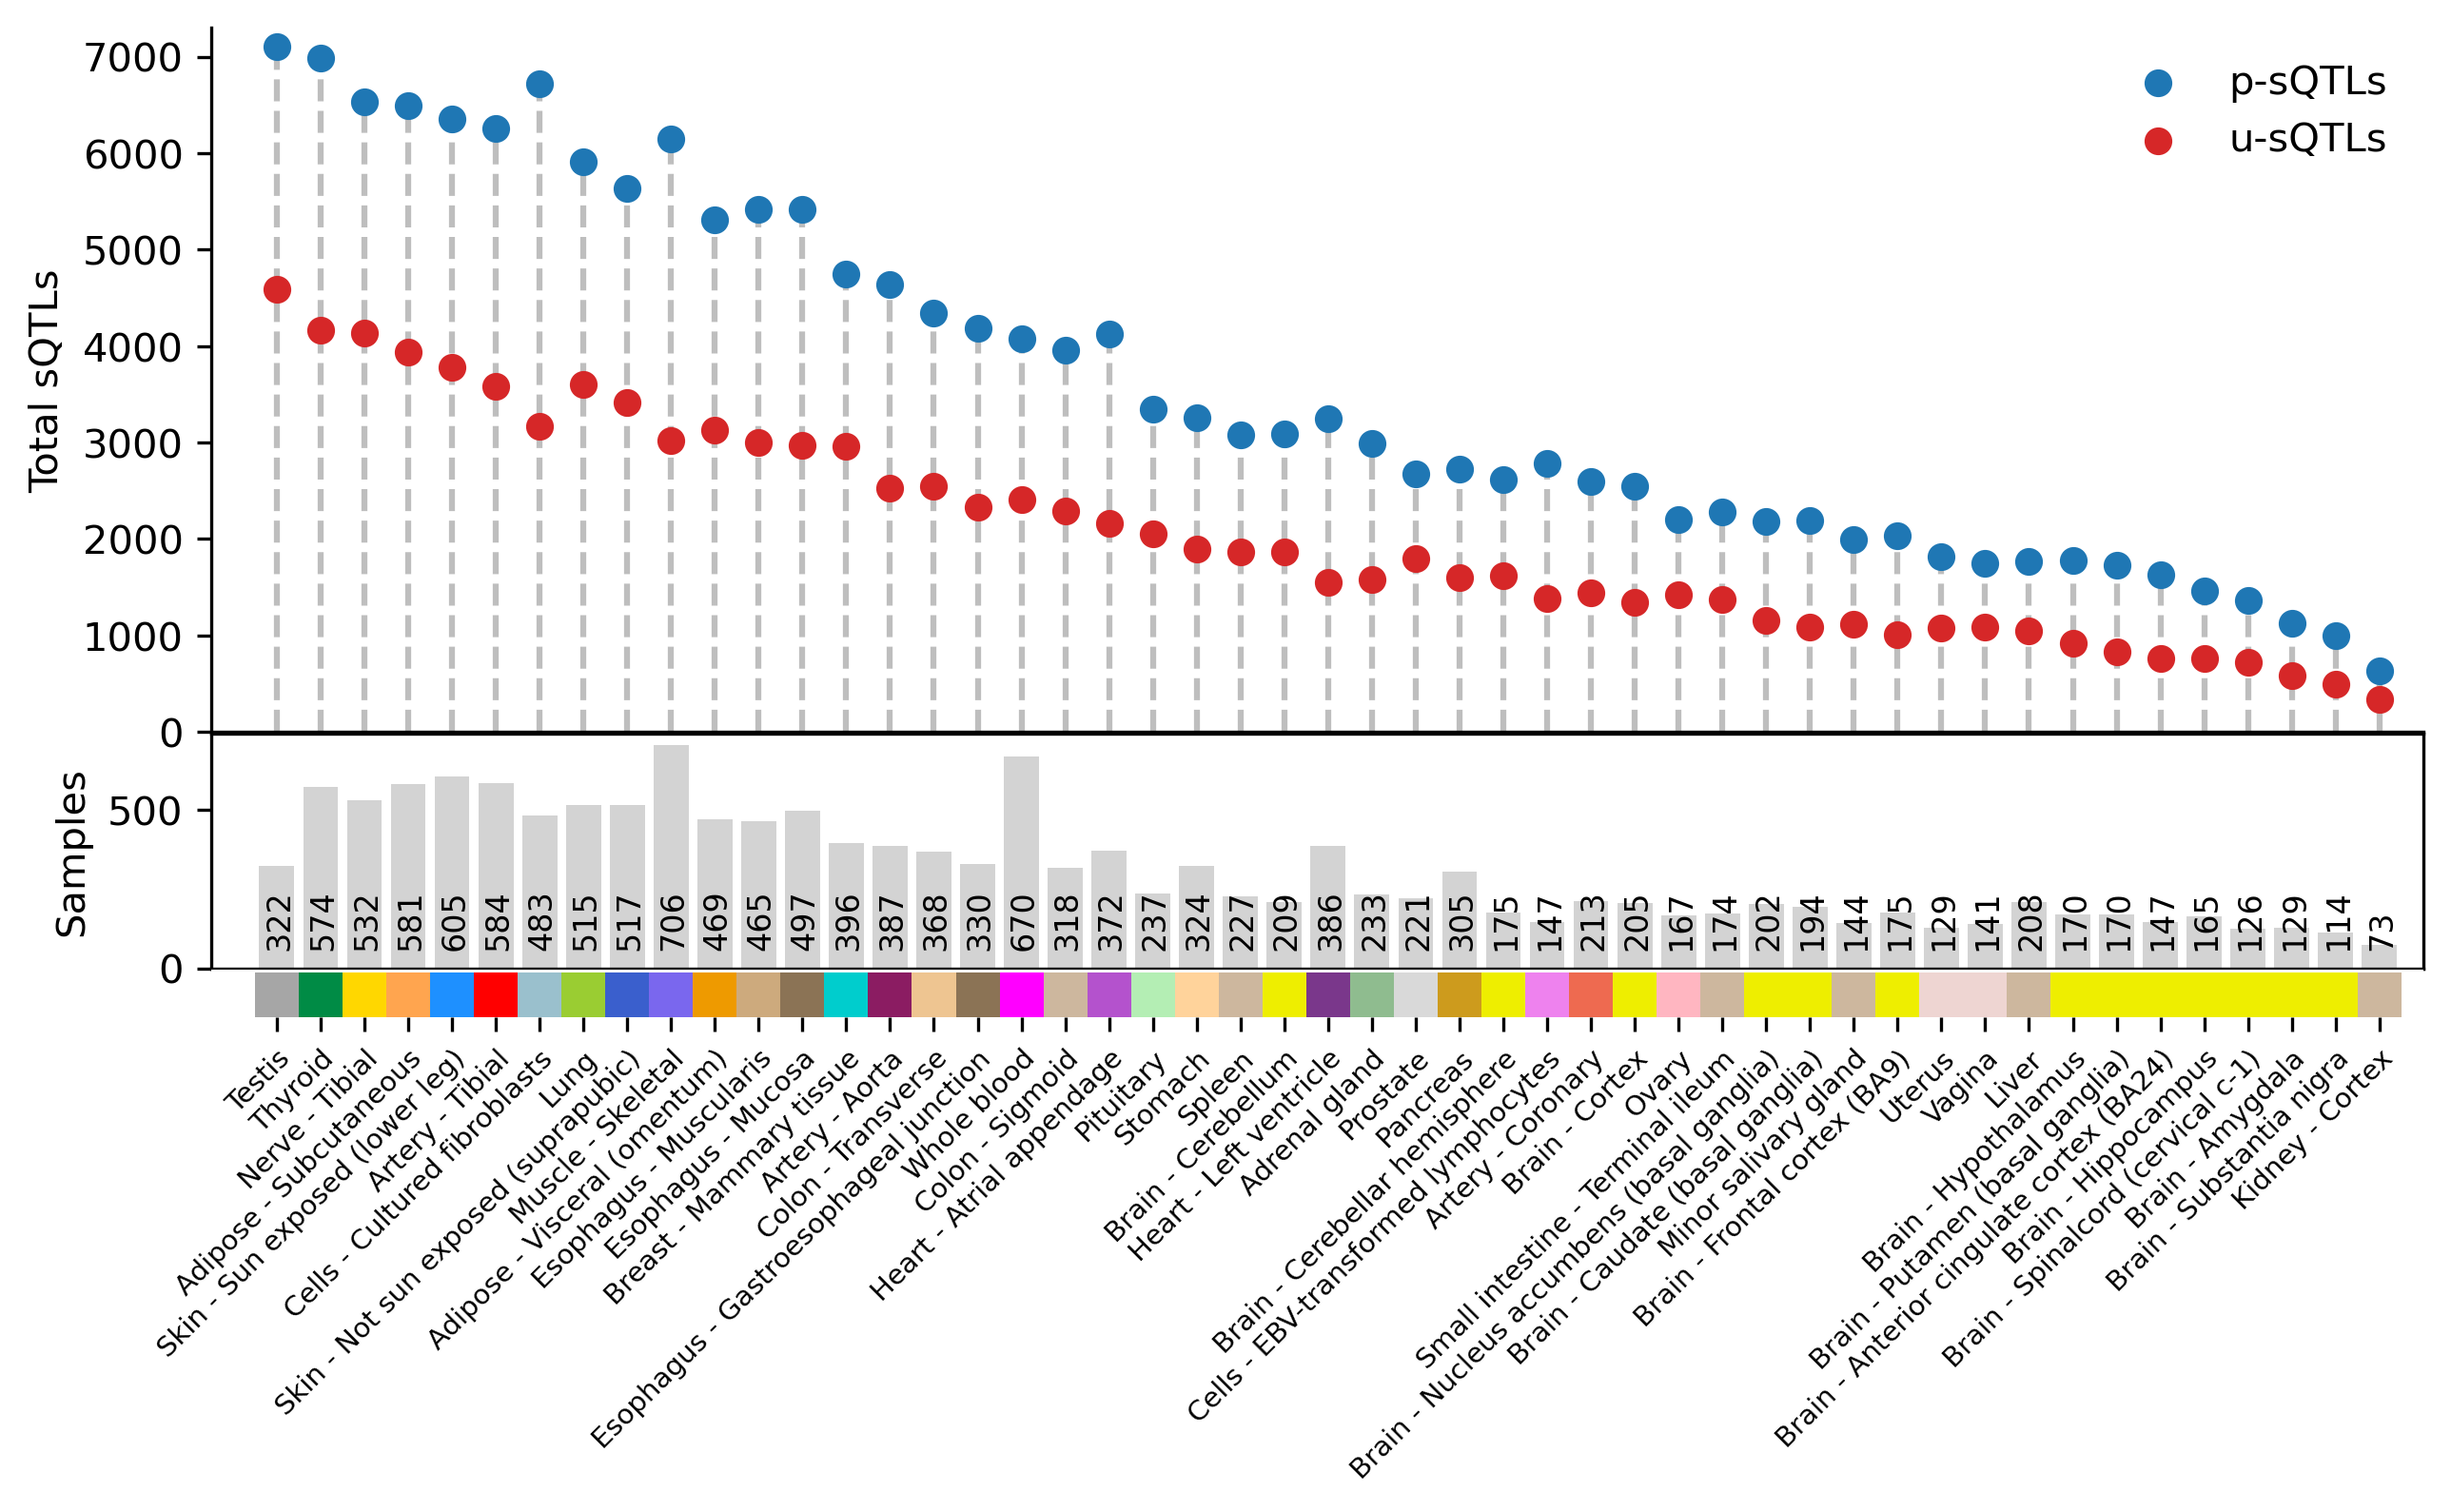

In [24]:
from tqdm import tqdm

fig, axes = plt.subplots(figsize = (10, 4.5), nrows=3, gridspec_kw={'height_ratios':[15, 5, 1], 'hspace':0.005}, dpi=300)
axes[0].scatter(
    np.arange(49)+0.5, np.array(qtl_dataframe.loc[sorted_tissues, 'PR']), 
    c= 'tab:blue', label='p-sQTLs', zorder=1# s=s
)

axes[0].scatter(np.arange(49)+0.5, 
    np.array(qtl_dataframe.loc[sorted_tissues, 'UP']),
    c= 'tab:red', label='u-sQTLs', zorder=2# s=s
)

n_samples = []
for i in tqdm(np.arange(49), position=0, leave=True):
    axes[0].plot([i+0.5, i+0.5], [0, qtl_dataframe.loc[sorted_tissues[i], 'PR']], linestyle='--', c='tab:gray', zorder=0, alpha=0.5)

    perm = pd.read_csv(f'../code/results/sqtl/GTEx/{sorted_tissues[i]}/cis_100000/perm/PermutationPass.Qval.txt.gz', sep='\t')
    n_samples.append((perm.dof1+2).iloc[0])
    axes[1].text(i+0.2, 80, str(n_samples[i]), rotation=90, fontsize=8)

    


# axes[0].scatter(np.arange(49)+0.5, 
#     np.array(qtl_dataframe.loc[sorted_tissues, 'Other']),
#     c= 'tab:orange', label='Other sQTLs', zorder=1, # s=s
# )


axes[1].bar(np.arange(49)+0.5, n_samples, width =0.8, color='lightgray')

axes[2].bar(np.arange(49)+0.5, [1]*49, width =1, color=c_list)

# axes[0].barh(range(49), [1]*49, height =1, color=c_list)


# plt.scatter(
#     np.array(sqtl_stats.loc[sqtl_stats.sqtl_type == 'p_sqtl'].set_index('tissue').loc[sorted_tissues].pearson_rho),
#     range(49)
# )

axes[0].set_xticks([])
axes[1].set_xticks([])
axes[1].set_ylabel('Samples')
axes[2].set_xticks([])
axes[2].spines[['top', 'bottom', 'right', 'left']].set_visible(False)
axes[2].set_yticks([])


axes[2].set_xlim([-1,49.5])
axes[1].set_xlim([-1,49.5])
axes[0].set_ylim([0,7300])
axes[0].set_xlim([-1,49.5])
axes[0].set_ylabel('Total sQTLs')
# axes[1].set_xlabel('Tissues')
axes[0].legend(frameon=False)
axes[0].spines[['top', 'right']].set_visible(False)

axes[2].set_xticks(np.arange(49)+0.5, sorted_tissues_renamed, rotation=45, ha='right', rotation_mode='anchor', size=7)

plt.savefig('../code/plots/fig4A.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4A.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4A.svg', dpi=300, bbox_inches='tight')

In [37]:
from scipy.stats import spearmanr, pearsonr
spearmanr(list(qtl_dataframe.loc[sorted_tissues].total), n_samples)

SignificanceResult(statistic=np.float64(0.9219308140669543), pvalue=np.float64(5.4757095994316284e-21))

In [38]:
perm_counts = get_perm_counts('Testis')

In [39]:
perm_counts.loc[(perm_counts.q <= 0.1) & (perm_counts.ctype == 'PR,UP')].itype.value_counts()

itype
PR    2316
UP    2273
Name: count, dtype: int64

In [40]:
perm_counts.loc[(perm_counts.q <= 0.1) & (perm_counts.ctype.apply(lambda x: 'UP' in x))].ctype.value_counts()

ctype
PR,UP          4589
NE,PR,UP        962
UP               21
IN,PR,UP          5
IN,NE,PR,UP       5
NE,UP             1
Name: count, dtype: int64

In [41]:
perm_counts.loc[perm_counts.q <= 0.1].itype.value_counts()

itype
PR    12194
UP     2539
NE     1776
IN      168
Name: count, dtype: int64

In [42]:
import numpy as np
from scipy.stats import chi2

def p_lambda(p_values, df=1, q=0.5):
    """
    Calculate the lambda inflation factor from a distribution of p-values.

    Parameters:
    - p_values: array-like, list or numpy array of p-values.
    - df: int, degrees of freedom for the chi-squared test (default is 1).

    Returns:
    - lambda_gc: float, the genomic control inflation factor.
    """
    if len(p_values) == 0:
        raise ValueError("The p-values list cannot be empty.")
    
    # Filter out invalid p-values
    p_values = np.asarray(p_values)
    if np.any((p_values < 0) | (p_values > 1)):
        raise ValueError("All p-values must be between 0 and 1.")
    
    # Convert p-values to chi-squared statistics
    chi_squared_stats = chi2.isf(p_values, df)
    
    # Calculate the observed median chi-squared statistic
    median_observed = np.quantile(chi_squared_stats, q)#np.median(chi_squared_stats)
    
    # Calculate the expected median chi-squared statistic under the null hypothesis
    median_expected = chi2.ppf(q, df)
    
    # Calculate lambda inflation factor
    lambda_gc = median_observed / median_expected
    
    return lambda_gc

# Example usage
p_values = [0.05, 0.01, 0.02, 0.03, 0.1, 0.2]
lambda_value = p_lambda(p_values)
print(f"Lambda Inflation Factor: {lambda_value:.3f}")


Lambda Inflation Factor: 9.398


In [41]:
from tqdm import tqdm
tissues = sorted(os.listdir('../code/results/sqtl/GTEx/'))
sqtl_stats = {}
for tissue in tqdm(tissues, position=0, leave=True):
    perm_counts = get_perm_counts(tissue)
    u_sqtl_effects = get_sqtl_expression_effects(perm_counts, tissue, ctype='PR,UP', itype='UP', qmax = 1e-1, clu_psi_min=0.1)
    p_sqtl_effects = get_sqtl_expression_effects(perm_counts, tissue, ctype='PR,UP', itype='PR', qmax = 1e-1, clu_psi_min=0.1)
    pp_sqtl_effects = get_sqtl_expression_effects(perm_counts, tissue, ctype='PR', itype='PR', qmax = 1e-1, clu_psi_min=0.1)
    
    u_sqtl_pearson = pearsonr(u_sqtl_effects[0], u_sqtl_effects[1])
    p_sqtl_pearson = pearsonr(p_sqtl_effects[0], p_sqtl_effects[1])
    pp_sqtl_pearson = pearsonr(pp_sqtl_effects[0], pp_sqtl_effects[1])
    
    u_sqtl_spearman = spearmanr(u_sqtl_effects[0], u_sqtl_effects[1])
    p_sqtl_spearman = spearmanr(p_sqtl_effects[0], p_sqtl_effects[1])
    pp_sqtl_spearman = spearmanr(pp_sqtl_effects[0], pp_sqtl_effects[1])
    
    u_sqtl_lambda = p_lambda(u_sqtl_effects[2])
    p_sqtl_lambda = p_lambda(p_sqtl_effects[2])
    pp_sqtl_lambda = p_lambda(pp_sqtl_effects[2])
    
    u_sqtl_lambda_90 = p_lambda(u_sqtl_effects[2], q=0.9)
    p_sqtl_lambda_90 = p_lambda(p_sqtl_effects[2], q=0.9)
    pp_sqtl_lambda_90 = p_lambda(pp_sqtl_effects[2], q=0.9)
    
    u_sqtl_n = len(u_sqtl_effects[0])
    p_sqtl_n = len(p_sqtl_effects[0])
    pp_sqtl_n = len(pp_sqtl_effects[0])
    
    tissue_dict = {
        'u_sqtl':{
            'pearson_rho':u_sqtl_pearson[0],
            'pearson_pval':u_sqtl_pearson[1],
            'spearman_rho':u_sqtl_spearman[0],
            'spearman_pval':u_sqtl_spearman[1],
            'lambda':u_sqtl_lambda,
            'lambda_90':u_sqtl_lambda_90,
            'n':u_sqtl_n
        },
        'p_sqtl':{
            'pearson_rho':p_sqtl_pearson[0],
            'pearson_pval':p_sqtl_pearson[1],
            'spearman_rho':p_sqtl_spearman[0],
            'spearman_pval':p_sqtl_spearman[1],
            'lambda':p_sqtl_lambda,
            'lambda_90':p_sqtl_lambda_90,
            'n':p_sqtl_n
        },
        'pp_sqtl':{
            'pearson_rho':pp_sqtl_pearson[0],
            'pearson_pval':pp_sqtl_pearson[1],
            'spearman_rho':pp_sqtl_spearman[0],
            'spearman_pval':pp_sqtl_spearman[1],
            'lambda':pp_sqtl_lambda,
            'lambda_90':pp_sqtl_lambda_90,
            'n':pp_sqtl_n
        }
    }
    
    sqtl_stats.update({tissue:tissue_dict})

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 49/49 [25:19<00:00, 31.01s/it]


In [31]:
def flatten_dict(d, parent_key=None):
    rows = []
    for key, value in d.items():
        if isinstance(value, dict):  # If the value is a nested dictionary
            rows.extend(flatten_dict(value, parent_key=([*parent_key, key] if parent_key else [key])))
        else:  # Leaf node
            rows.append((parent_key + [key] if parent_key else [key]) + [value])
    return rows

In [32]:
def dict_to_dataframe(d):
    rows = []

    def traverse(current_dict, path):
        if isinstance(current_dict, dict):
            for key, value in current_dict.items():
                traverse(value, path + [key])
        else:
            # Leaf node: add a new row to the list
            rows.append(path + [current_dict])

    traverse(d, [])
#     print(rows)
    # Convert the rows into a DataFrame
    return pd.DataFrame(rows, columns=[f'col{i+1}' for i in range(len(rows[0]) - 2)] + ['X', 'Y'])


In [44]:
sqtl_stats = dict_to_dataframe(sqtl_stats).pivot(index=['col1', 'col2'], columns='X', values='Y').reset_index()
sqtl_stats.columns = ['tissue', 'sqtl_type', 'lambda_inflation', 'lambda_90', 'n', 'pearson_pval', 'pearson_rho', 'spearman_pval', 'spearman_rho']

In [101]:
# sqtl_stats.to_csv('sQTL_stats.tsv.gz', sep='\t', index=False, header=True)
sqtl_stats = pd.read_csv('sQTL_stats.tsv.gz', sep='\t')

In [102]:
sorted_tissues = list(sqtl_stats.loc[sqtl_stats.sqtl_type == 'u_sqtl'].sort_values('spearman_pval').tissue)[::-1]

In [35]:
s = []
for n_ in np.array(sqtl_stats.loc[sqtl_stats.sqtl_type == 'u_sqtl'].set_index('tissue').loc[sorted_tissues].n):
    if n_ <= 100:
        s.append(3)
    elif n_ <= 200:
        s.append(10)
    elif n_ <= 500:
        s.append(40)
    else:
        s.append(80)

In [36]:
s_ = []
for n_ in np.array(sqtl_stats.loc[sqtl_stats.sqtl_type == 'pp_sqtl'].set_index('tissue').loc[sorted_tissues].n):
    if n_ <= 100:
        s_.append(3)
    elif n_ <= 200:
        s_.append(10)
    elif n_ <= 500:
        s_.append(40)
    else:
        s_.append(80)

In [37]:
sorted_tissues = list(sqtl_stats.loc[sqtl_stats.sqtl_type == 'u_sqtl'].sort_values('spearman_pval').tissue)[::-1]
c_list = []
for tissue in sorted_tissues:
    c = '#' + gtex_colors[tissue]['tissue_color_hex']
    c_list.append(c)

In [38]:
sqtl_stats.loc[(sqtl_stats.spearman_rho > 0) & (sqtl_stats.sqtl_type == 'u_sqtl')]

,tissue,sqtl_type,lambda_inflation,lambda_90,n,pearson_pval,pearson_rho,spearman_pval,spearman_rho
29,Brain-CerebellarHemisphere,u_sqtl,10.729137,21.302778,703.0,0.270872,0.041583,0.665829,0.016317
128,Spleen,u_sqtl,12.201712,21.841844,807.0,0.566592,0.020203,0.799381,0.008960


In [39]:
sorted_tissues_sig = list(sqtl_stats.loc[(sqtl_stats.sqtl_type == 'u_sqtl') & (sqtl_stats.spearman_pval <= 0.05)
                                        ].sort_values('spearman_pval').tissue)[::-1]

In [40]:
sqtl_stats.loc[sqtl_stats.sqtl_type == 'pp_sqtl'].spearman_pval.min()

np.float64(0.1427169854858456)

In [65]:
n1 = len(sqtl_stats.loc[(sqtl_stats.sqtl_type == 'u_sqtl') & (sqtl_stats.spearman_pval <= 1e-10)].tissue)
n2 = len(sqtl_stats.loc[(sqtl_stats.sqtl_type == 'u_sqtl') & (sqtl_stats.spearman_pval <= 1e-4)].tissue) - n1
n3 = len(sqtl_stats.loc[(sqtl_stats.sqtl_type == 'u_sqtl') & (sqtl_stats.spearman_pval <= 5e-2)].tissue) - n1 - n2
n4 = len(sqtl_stats.loc[(sqtl_stats.sqtl_type == 'u_sqtl') & (sqtl_stats.spearman_pval > 5e-2)].tissue)

In [66]:
sorted_tissues = list(sqtl_stats.loc[sqtl_stats.sqtl_type == 'u_sqtl'].sort_values('spearman_pval').tissue)[::-1]
c_list = []
for tissue in sorted_tissues:
    c = '#' + gtex_colors[tissue]['tissue_color_hex']
    c_list.append(c)

In [69]:
sorted_tissues_names = ['Brain - Cerebellum',
 'Spleen',
 'Brain - Cerebellar hemisphere',
 'Brain - Substantia nigra',
 'Kidney - Cortex',
 'Brain - Amygdala',
 'Small intestine - Terminal ileum',
 'Brain - Nucleus accumbens (basal ganglia)',
 'Brain - Anterior cingulate cortex (BA24)',
 'Brain - Frontal cortex (BA9)',
 'Pituitary',
 'Brain - Hippocampus',
 'Prostate',
 'Whole blood',
 'Brain - Spinal cord (cervical c-1)',
 'Brain - Hypothalamus',
 'Liver',
 'Uterus',
 'Brain - Cortex',
 'Brain - Putamen (basal ganglia)',
 'Vagina',
 'Brain - Caudate (basal ganglia)',
 'Colon - Sigmoid',
 'Thyroid',
 'Esophagus - Gastroesophageal junction',
 'Heart - Left ventricle',
 'Nerve - Tibial',
 'Artery - Coronary',
 'Ovary',
 'Heart - Atrial appendage',
 'Lung',
 'Stomach',
 'Pancreas',
 'Colon - Transverse',
 'Esophagus - Muscularis',
 'Adipose - Subcutaneous',
 'Skin - Sun exposed (lower leg)',
 'Minor salivary gland',
 'Breast - Mammary tissue',
 'Adrenal gland',
 'Adipose - Visceral (omentum)',
 'Artery - Aorta',
 'Skin - Not sun exposed (suprapubic)',
 'Testis',
 'Cells - EBV-transformed lymphocytes',
 'Artery - Tibial',
 'Esophagus - Mucosa',
 'Muscle - Skeletal',
 'Cells - Cultured fibroblasts']

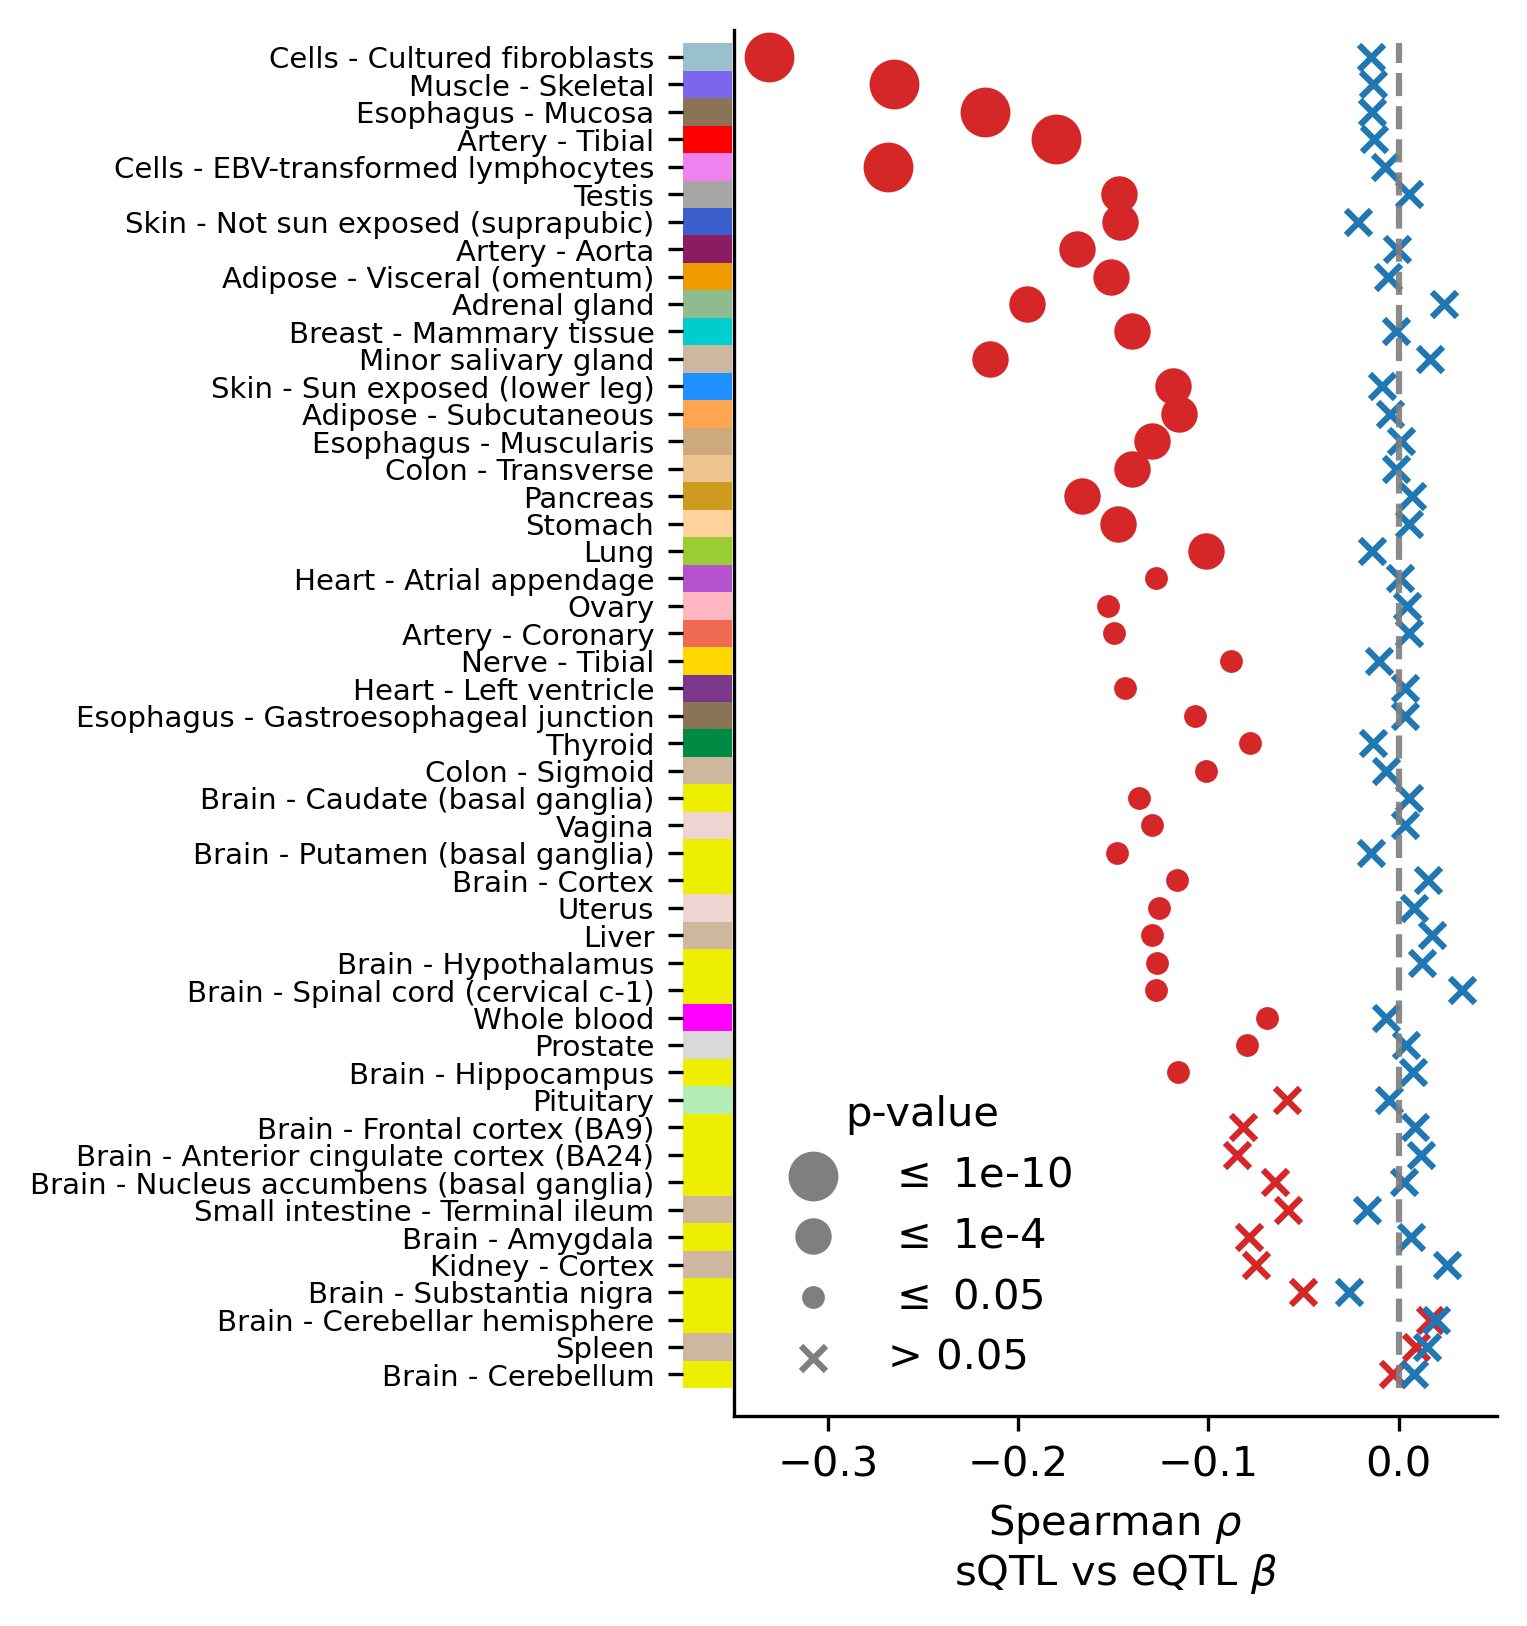

In [70]:
fig, axes = plt.subplots(figsize = (3.5, 6), ncols=2, gridspec_kw={'width_ratios':[1,15], 'wspace':0}, dpi=300)


axes[1].scatter(
    np.array(sqtl_stats.loc[(sqtl_stats.sqtl_type == 'u_sqtl')].set_index('tissue').loc[sorted_tissues[:n4]].spearman_rho),
    np.arange(n4)+0.5, c= 'tab:red', marker='x'
)

axes[1].scatter(
    np.array(sqtl_stats.loc[sqtl_stats.sqtl_type == 'pp_sqtl'].set_index('tissue').loc[sorted_tissues[:n4]].spearman_rho),
    np.arange(n4)+0.5, c='tab:blue', marker='x'
)






axes[1].scatter(
    np.array(sqtl_stats.loc[sqtl_stats.sqtl_type == 'u_sqtl'].set_index('tissue').loc[sorted_tissues[n4:(n4+n3)]].spearman_rho),
    np.arange(n3)+0.5+n4, c= 'tab:red',s=20
)

axes[1].scatter(
    np.array(sqtl_stats.loc[sqtl_stats.sqtl_type == 'pp_sqtl'].set_index('tissue').loc[sorted_tissues[n4:(n4+n3)]].spearman_rho),
    np.arange(n3)+0.5+n4, c='tab:blue',  marker='x'
)






axes[1].scatter(
    np.array(sqtl_stats.loc[sqtl_stats.sqtl_type == 'u_sqtl'].set_index('tissue').loc[sorted_tissues[(n4+n3):(n4+n3+n2)]].spearman_rho),
    np.arange(n2)+0.5+n4+n3, c= 'tab:red',  s=60
)

axes[1].scatter(
    np.array(sqtl_stats.loc[sqtl_stats.sqtl_type == 'pp_sqtl'].set_index('tissue').loc[sorted_tissues[(n4+n3):(n4+n3+n2)]].spearman_rho),
    np.arange(n2)+0.5+n4+n3, c='tab:blue', marker='x'
)










axes[1].scatter(
    np.array(sqtl_stats.loc[sqtl_stats.sqtl_type == 'u_sqtl'].set_index('tissue').loc[sorted_tissues[(n4+n3+n2):]].spearman_rho),
    np.arange(n1)+0.5+n4+n3+n2, c= 'tab:red',  s=120
)

axes[1].scatter(
    np.array(sqtl_stats.loc[sqtl_stats.sqtl_type == 'pp_sqtl'].set_index('tissue').loc[sorted_tissues[(n4+n3+n2):]].spearman_rho),
    np.arange(n1)+0.5+n4+n3+n2, c='tab:blue',  marker='x'
)







# axes[1].plot([-0.3, 0.05], [49-34, 49-34], c='tab:gray', alpha=0.9, linestyle='--')

axes[0].barh(np.arange(49)+0.5, [1]*49, height =1, color=c_list)

axes[1].plot([0,0], [0, 49], c='tab:gray', alpha=0.9, linestyle='--')
# axes[1].text(-0.3, 49-31+1, 'p-val = 0.05', c='black', alpha=0.9)

# plt.scatter(
#     np.array(sqtl_stats.loc[sqtl_stats.sqtl_type == 'p_sqtl'].set_index('tissue').loc[sorted_tissues].pearson_rho),
#     range(49)
# )

axes[1].scatter([0], [100], c='tab:gray', s=120, label=r'$\leq$ 1e-10')
axes[1].scatter([0], [100], c='tab:gray', s=60, label=r'$\leq$ 1e-4')
axes[1].scatter([0], [100], c='tab:gray', s=20, label=r'$\leq$ 0.05')

axes[1].scatter([0], [100], c='tab:gray', marker='x', label=r'> 0.05')

axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].spines[['top', 'bottom', 'right', 'left']].set_visible(False)
axes[1].set_yticks([])

axes[0].set_ylim([-1,49.5])
axes[1].set_ylim([-1,49.5])
axes[1].set_xlabel(r'Spearman $\rho$' + '\nsQTL vs eQTL' + r' $\beta$')
# axes[0].set_ylabel('Tissues (ranked by significance)')




axes[1].legend(frameon=False, title='p-value')
axes[1].spines[['top', 'right']].set_visible(False)


axes[0].set_yticks(np.arange(49)+0.5, sorted_tissues_names, rotation=0, ha='right', rotation_mode='anchor', size=7)


plt.savefig('../code/plots/fig4B.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4B.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4B.svg', dpi=300, bbox_inches='tight')

In [40]:
perm_counts = get_perm_counts('Cells-Culturedfibroblasts')
u_sqtl_effects = get_sqtl_expression_effects(perm_counts, 'Cells-Culturedfibroblasts', ctype='PR,UP', itype='UP', qmax = 1e-1, clu_psi_min=0.1)
p_sqtl_effects = get_sqtl_expression_effects(perm_counts, 'Cells-Culturedfibroblasts', ctype='PR,UP', itype='PR', qmax = 1e-1, clu_psi_min=0.1)
pp_sqtl_effects = get_sqtl_expression_effects(perm_counts, 'Cells-Culturedfibroblasts', ctype='PR', itype='PR', qmax = 1e-1, clu_psi_min=0.1)

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy import stats

In [53]:
slope, intercept, r_value, p_value, std_err = linregress(u_sqtl_effects[0], u_sqtl_effects[1])
n = len(u_sqtl_effects[0])
t_value = stats.t.ppf(0.975, n-2)  # 95% confidence interval
conf_int = t_value * std_err

In [93]:
len(u_sqtl_effects[1])

1391

In [161]:
spearmanr(u_sqtl_effects[0], u_sqtl_effects[1])

SignificanceResult(statistic=-0.33092226325523055, pvalue=6.695905472288544e-37)

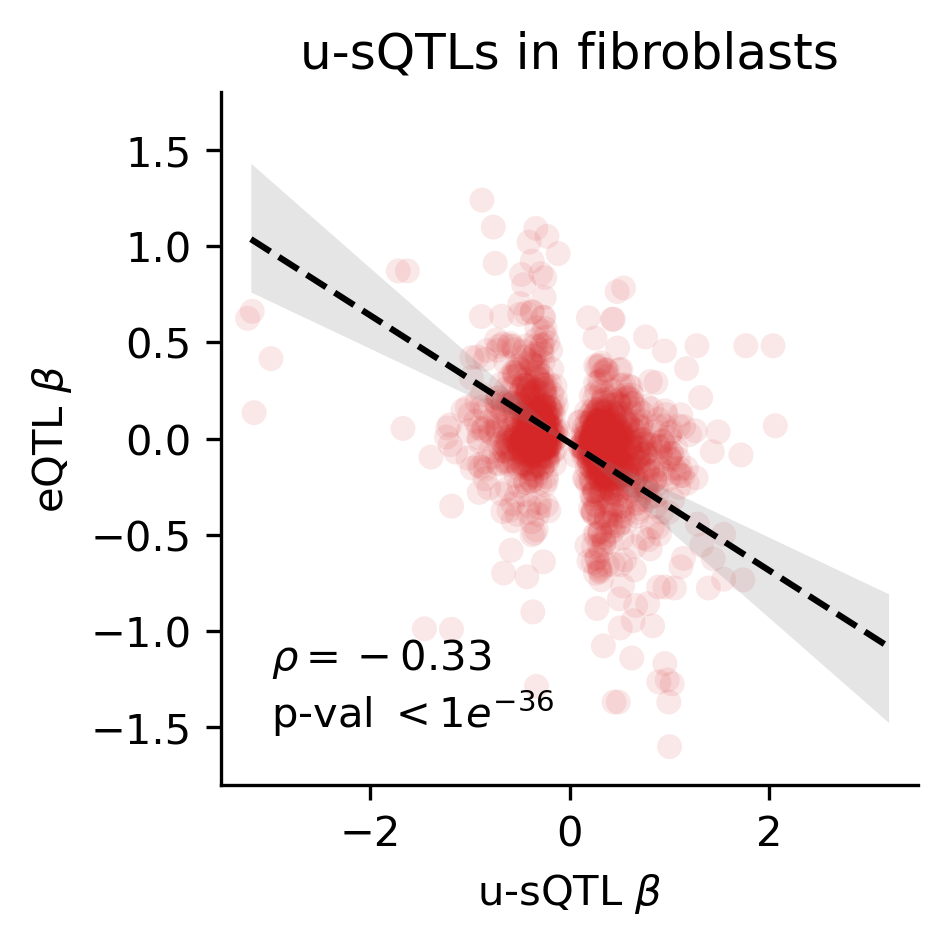

In [181]:
rho_list = []
for i in range(100):
    idx = np.random.choice(np.arange(1391), 100, replace=False)
    rho_list.append(spearmanr(np.array(u_sqtl_effects[0])[idx], np.array(u_sqtl_effects[1])[idx])[0])
    
fig, ax = plt.subplots(figsize=(3, 3), dpi=300)
plt.scatter(u_sqtl_effects[0], u_sqtl_effects[1], facecolor='tab:red', edgecolor='none', alpha=0.1, rasterized=True)


slope = spearmanr(u_sqtl_effects[0], u_sqtl_effects[1])[0]
intercept = np.mean(u_sqtl_effects[1])
slope_90 = np.quantile(rho_list, 0.9)
slope_10 = np.quantile(rho_list, 0.1)

# Plot confidence intervals (optional)

x = np.linspace(-3.2, 3.2, 100)

ax.plot(x, slope * x + intercept, color='black', linestyle='--')


ax.fill_between(x,( slope_90 * np.array(x)) + intercept, 
                (slope_10 * x) + intercept, 
                 color='tab:gray', alpha=0.2, label='Confidence Interval', linewidth=0)

ax.set_xlim([-3.5, 3.5])

ax.set_ylim([-1.8, 1.8])

ax.spines[['top', 'right']].set_visible(False)

ax.text(-3, -1.5, r'$\rho = -0.33$' + '\np-val $< 1e^{-36}$')
ax.set_xlabel(r'u-sQTL $\beta$')
ax.set_ylabel(r'eQTL $\beta$')
ax.set_title('u-sQTLs in fibroblasts')
plt.savefig('../code/plots/fig4B1.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4B1.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4B1.svg', dpi=300, bbox_inches='tight')

Text(0.5, -1, '$\\rho = 0.13$\np-val $< 1e^{-6}$')

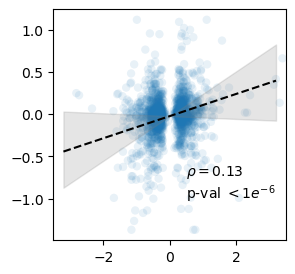

In [155]:
rho_list = []
for i in range(100):
    idx = np.random.choice(np.arange(len(p_sqtl_effects[0])), 100, replace=False)
    rho_list.append(spearmanr(np.array(p_sqtl_effects[0])[idx], np.array(p_sqtl_effects[1])[idx])[0])


fig, ax = plt.subplots(figsize=(3, 3))
plt.scatter(p_sqtl_effects[0], p_sqtl_effects[1], facecolor='tab:blue', edgecolor='none', alpha=0.1)


slope = spearmanr(p_sqtl_effects[0], p_sqtl_effects[1])[0]
intercept = np.mean(p_sqtl_effects[1])
slope_90 = np.quantile(rho_list, 0.9)
slope_10 = np.quantile(rho_list, 0.1)

# Plot confidence intervals (optional)

x = np.linspace(-3.2, 3.2, 100)

ax.plot(x, slope * x + intercept, color='black', linestyle='--')


ax.fill_between(x,( slope_90 * np.array(x)) + intercept, 
                (slope_10 * x) + intercept, 
                 color='tab:gray', alpha=0.2, label='Confidence Interval')

ax.set_xlim([-3.5, 3.5])

ax.text(0.5, -1, r'$\rho = 0.13$' + '\np-val $< 1e^{-6}$')

In [149]:
spearmanr(p_sqtl_effects[0], p_sqtl_effects[1])

SignificanceResult(statistic=0.13117175637683334, pvalue=2.667986670426227e-07)

In [157]:
spearmanr(pp_sqtl_effects[0], pp_sqtl_effects[1])

SignificanceResult(statistic=-0.014591402754633208, pvalue=0.2571803960245302)

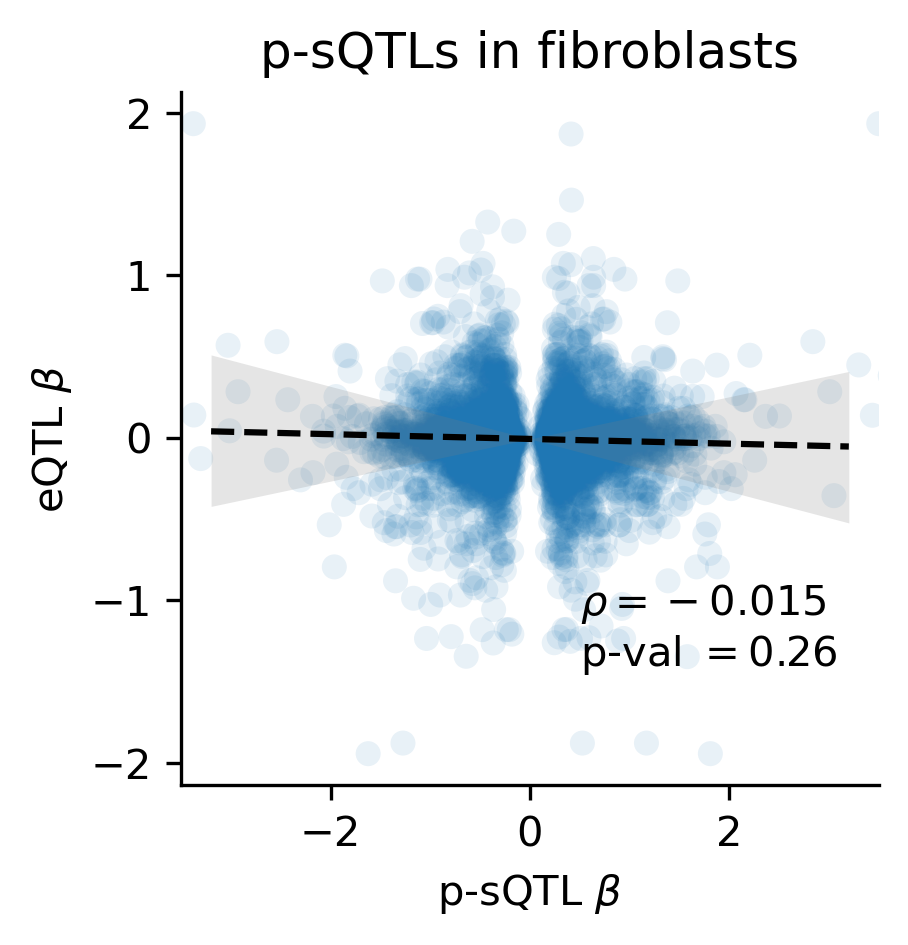

In [199]:
rho_list = []
for i in range(100):
    idx = np.random.choice(np.arange(len(pp_sqtl_effects[0])), 100, replace=False)
    rho_list.append(spearmanr(np.array(pp_sqtl_effects[0])[idx], np.array(pp_sqtl_effects[1])[idx])[0])


fig, ax = plt.subplots(figsize=(3, 3), dpi=300)
plt.scatter(pp_sqtl_effects[0], pp_sqtl_effects[1], facecolor='tab:blue', edgecolor='none', alpha=0.1, rasterized=True)


slope = spearmanr(pp_sqtl_effects[0], pp_sqtl_effects[1])[0]
intercept = np.mean(pp_sqtl_effects[1])
slope_90 = np.quantile(rho_list, 0.9)
slope_10 = np.quantile(rho_list, 0.1)

# Plot confidence intervals (optional)

x = np.linspace(-3.2, 3.2, 100)

ax.plot(x, slope * x + intercept, color='black', linestyle='--')


ax.fill_between(x,( slope_90 * np.array(x)) + intercept, 
                (slope_10 * x) + intercept, 
                 color='tab:gray', alpha=0.2, label='Confidence Interval', linewidth=0)

ax.set_xlim([-3.5, 3.5])

ax.text(0.5, -1.4, r'$\rho = -0.015$' + '\np-val $= 0.26$')

ax.spines[['top', 'right']].set_visible(False)

ax.set_xlabel(r'p-sQTL $\beta$')
ax.set_ylabel(r'eQTL $\beta$')
ax.set_title('p-sQTLs in fibroblasts')

plt.savefig('../code/plots/fig4B2.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4B2.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4B2.svg', dpi=300, bbox_inches='tight')

In [172]:
spearmanr(pp_sqtl_effects[0], pp_sqtl_effects[1])

SignificanceResult(statistic=-0.014591402754633208, pvalue=0.2571803960245302)

In [72]:
intercept

-0.010579648692715151

In [57]:
p_value

1.006517052139853e-37

In [121]:
(slope - conf_int) * np.array(u_sqtl_effects[0]) + intercept

array([ 0.20849863,  0.12837353, -0.13696136, ..., -0.26615808,
        0.11719558, -0.19692295])

In [122]:
(slope + conf_int) * np.array(u_sqtl_effects[0]) + intercept

array([ 0.17550099,  0.10684343, -0.12051661, ..., -0.23122264,
        0.09726528, -0.17189647])

In [123]:
f1

array([10.        ,  9.98998999,  9.97997998,  9.96996997,  9.95995996,
        9.94994995,  9.93993994,  9.92992993,  9.91991992,  9.90990991,
        9.8998999 ,  9.88988989,  9.87987988,  9.86986987,  9.85985986,
        9.84984985,  9.83983984,  9.82982983,  9.81981982,  9.80980981,
        9.7997998 ,  9.78978979,  9.77977978,  9.76976977,  9.75975976,
        9.74974975,  9.73973974,  9.72972973,  9.71971972,  9.70970971,
        9.6996997 ,  9.68968969,  9.67967968,  9.66966967,  9.65965966,
        9.64964965,  9.63963964,  9.62962963,  9.61961962,  9.60960961,
        9.5995996 ,  9.58958959,  9.57957958,  9.56956957,  9.55955956,
        9.54954955,  9.53953954,  9.52952953,  9.51951952,  9.50950951,
        9.4994995 ,  9.48948949,  9.47947948,  9.46946947,  9.45945946,
        9.44944945,  9.43943944,  9.42942943,  9.41941942,  9.40940941,
        9.3993994 ,  9.38938939,  9.37937938,  9.36936937,  9.35935936,
        9.34934935,  9.33933934,  9.32932933,  9.31931932,  9.30

In [103]:
lambda_enrichment = pd.DataFrame(sqtl_stats.loc[sqtl_stats.sqtl_type == 'u_sqtl'].set_index('tissue').loc[sorted_tissues].lambda_inflation/sqtl_stats.loc[sqtl_stats.sqtl_type == 'pp_sqtl'].set_index('tissue').loc[sorted_tissues].lambda_inflation)

In [104]:
sorted_lambda_tissues = sqtl_stats.loc[sqtl_stats.sqtl_type == 'u_sqtl'].set_index('tissue').sort_values('lambda_inflation').index[::-1]

In [105]:
c_list = []
for tissue in sorted_lambda_tissues:
    c = '#' + gtex_colors[tissue]['tissue_color_hex']
    c_list.append(c)

In [108]:
np.array(sqtl_stats.loc[sqtl_stats.sqtl_type == 'u_sqtl'].set_index('tissue').loc[sorted_lambda_tissues].lambda_inflation)

array([20.39865112, 19.56176103, 18.95957999, 18.70050168, 17.99849626,
       17.88953547, 17.21144352, 16.83457581, 16.49668417, 15.47070262,
       15.18410015, 15.00150103, 14.63433321, 14.22921504, 14.13624308,
       14.05909991, 13.75366539, 13.49548893, 13.09308018, 13.0415191 ,
       12.97529042, 12.20171154, 12.11380893, 11.91277261, 11.36815518,
       11.12913562, 10.72913703, 10.68774533, 10.57892781, 10.50888245,
       10.15541287, 10.11442672,  9.24845729,  9.08411672,  9.07411038,
        8.57960926,  8.37305906,  8.32727887,  8.25235811,  8.01922679,
        7.91766606,  7.90924732,  7.6703223 ,  6.7306183 ,  6.67723641,
        6.53558876,  6.44531241,  6.15195956,  5.96621142])

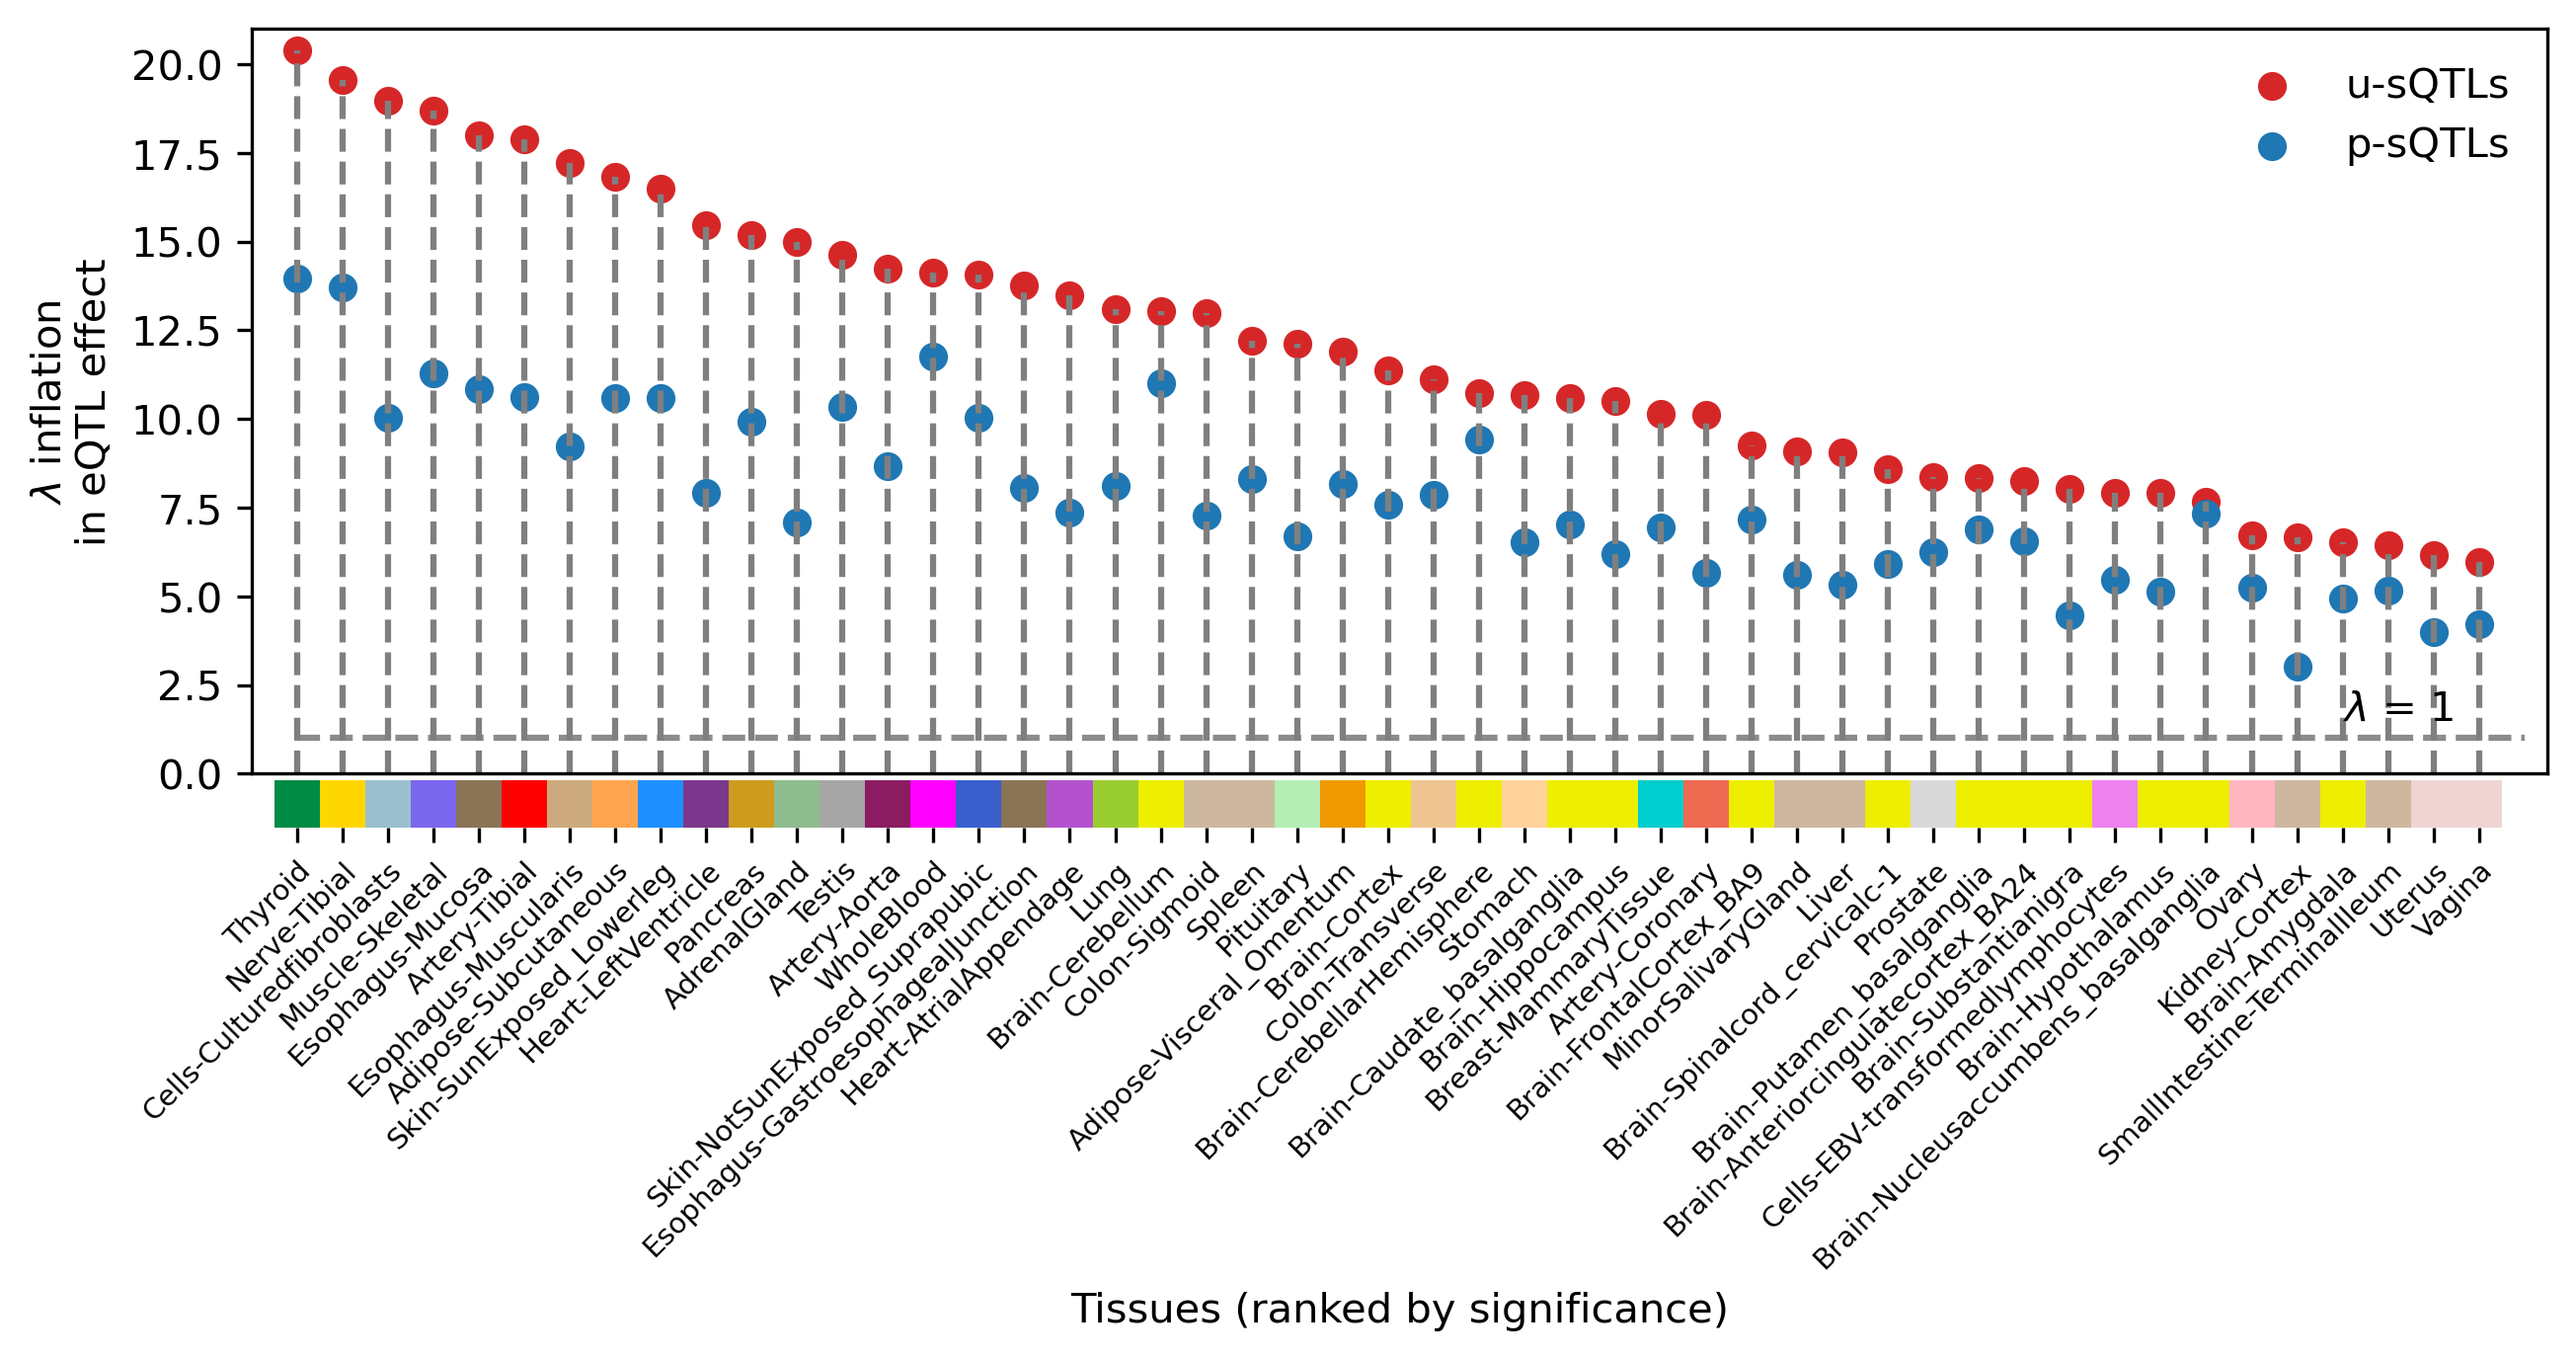

In [110]:
fig, axes = plt.subplots(figsize = (10, 3.5), nrows=2, gridspec_kw={'height_ratios':[15, 1], 'hspace':0.01}, dpi=300)

aver = np.array(sqtl_stats.loc[sqtl_stats.sqtl_type == 'u_sqtl'].set_index('tissue').loc[sorted_lambda_tissues].lambda_inflation)
for i in range(len(aver)):
    axes[0].plot(
        [i, i], 
        [0, aver[i]],
        c= 'tab:gray', linestyle='--', zorder=0
    )


axes[0].scatter(
    np.array(np.arange(49)), np.array(sqtl_stats.loc[sqtl_stats.sqtl_type == 'u_sqtl'].set_index('tissue').loc[sorted_lambda_tissues].lambda_inflation),
    c= 'tab:red', label='u-sQTLs'# s=s
)

axes[0].scatter(
    np.array(np.arange(49)), np.array(sqtl_stats.loc[sqtl_stats.sqtl_type == 'pp_sqtl'].set_index('tissue').loc[sorted_lambda_tissues].lambda_inflation),
    c= 'tab:blue', label='p-sQTLs'# s=s
)


axes[1].bar(range(49), [1]*49, width =1, color=c_list)

# axes[0].barh(range(49), [1]*49, height =1, color=c_list)

axes[0].plot([0, 49],[1,1], c='tab:gray', alpha=0.9, linestyle='--')

# plt.scatter(
#     np.array(sqtl_stats.loc[sqtl_stats.sqtl_type == 'p_sqtl'].set_index('tissue').loc[sorted_tissues].pearson_rho),
#     range(49)
# )

axes[0].set_xticks([])
axes[1].set_xticks([])
axes[1].spines[['top', 'bottom', 'right', 'left']].set_visible(False)
axes[1].set_yticks([])

axes[1].set_xlim([-1,49.5])
axes[0].set_xlim([-1,49.5])
axes[0].set_ylabel(r'$\lambda$ inflation' + '\nin eQTL effect')
axes[1].set_xlabel('Tissues (ranked by significance)')
axes[0].legend(frameon=False)
axes[0].set_ylim([0, 21])
axes[0].text(45, 1.5, r'$\lambda$ = 1')


axes[1].set_xticks(np.arange(49), sorted_lambda_tissues, rotation=45, ha='right', rotation_mode='anchor', size=7)

plt.savefig('../code/plots/fig4_supfig1.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_supfig1.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_supfig1.svg', dpi=300, bbox_inches='tight')

In [10]:
def get_var_eqtls(tissue, max_pvals = 10000):
    
    chroms = ['chr' + str(i) for i in range(1, 23)]
    epvals = []
    
    for chrom in chroms:
        nom_file = f'../code/results/eqtl/GTEx/Testis/cis_100000/nom/{chrom}.txt.gz'
        with gzip.open(nom_file, 'rb') as fh:
            fh.readline()
            for line in fh:
                row = line.decode().rstrip().split('\t')
                pval = float(row[11])
                epvals.append(pval)
#                 break
        
    epvals = np.random.choice(epvals, max_pvals, replace=False)
    return epvals


def get_expression_effect(tissue, perm_qtl):
    var_id = perm_qtl.var_id
    chrom = perm_qtl.var_chr
    start = str(int(perm_qtl.var_from) - 1)
    
    end = str(int(perm_qtl.var_to) + 1)
    
    coords = f'{chrom}:{start}:{end}'
    
    gene = perm_qtl.gene_id.split('.')[0]
            
    nom_file = f'../code/results/eqtl/GTEx/{tissue}/cis_100000/nom/{chrom}.txt.gz'
    nom_df = run_tabix_on_nom(nom_file, coords, transform_to_df=True)
    nom_df = nom_df.loc[(nom_df['#phe_id'] == gene) & (nom_df['var_id'] == var_id)]

    return nom_df

In [11]:
from tqdm import tqdm
tissues = sorted(os.listdir('../code/results/sqtl/GTEx/'))
sqtl_qq = {}
for tissue in tqdm(tissues, position=0, leave=True):
    perm_counts = get_perm_counts(tissue)
    u_sqtl_effects = get_sqtl_expression_effects(perm_counts, tissue, ctype='PR,UP', itype='UP', qmax = 1e-1, clu_psi_min=0.1)
#     p_sqtl_effects = get_sqtl_expression_effects(perm_counts, tissue, ctype='PR,UP', itype='PR', qmax = 1e-1, clu_psi_min=0.1)
    pp_sqtl_effects = get_sqtl_expression_effects(perm_counts, tissue, ctype='PR', itype='PR', qmax = 1e-1, clu_psi_min=0.1)

    max_sqtls = len(u_sqtl_effects[2])#, len(pp_sqtl_effects[2])])
    
    epvals = get_var_eqtls(tissue, max_pvals = max_sqtls)
    
    sqtl_qq.update({tissue:{
        'usQTLs':u_sqtl_effects[2],
        'ppsQTLs':pp_sqtl_effects[2],
        'eQTLs':epvals
    }})
#     u_sqtl_pearson = pearsonr(u_sqtl_effects[0], u_sqtl_effects[1])
#     p_sqtl_pearson = pearsonr(p_sqtl_effects[0], p_sqtl_effects[1])
#     pp_sqtl_pearson = pearsonr(pp_sqtl_effects[0], pp_sqtl_effects[1])
    
#     u_sqtl_spearman = spearmanr(u_sqtl_effects[0], u_sqtl_effects[1])
#     p_sqtl_spearman = spearmanr(p_sqtl_effects[0], p_sqtl_effects[1])
#     pp_sqtl_spearman = spearmanr(pp_sqtl_effects[0], pp_sqtl_effects[1])
    
#     u_sqtl_lambda = p_lambda(u_sqtl_effects[2])
#     p_sqtl_lambda = p_lambda(p_sqtl_effects[2])
#     pp_sqtl_lambda = p_lambda(pp_sqtl_effects[2])
    
    
    
#     u_sqtl_lambda_90 = p_lambda(u_sqtl_effects[2], q=0.9)
#     p_sqtl_lambda_90 = p_lambda(p_sqtl_effects[2], q=0.9)
#     pp_sqtl_lambda_90 = p_lambda(pp_sqtl_effects[2], q=0.9)
    
#     break
#     u_sqtl_n = len(u_sqtl_effects[0])
#     p_sqtl_n = len(p_sqtl_effects[0])
#     pp_sqtl_n = len(pp_sqtl_effects[0])
    
#     tissue_dict = {
#         'u_sqtl':{
#             'pearson_rho':u_sqtl_pearson[0],
#             'pearson_pval':u_sqtl_pearson[1],
#             'spearman_rho':u_sqtl_spearman[0],
#             'spearman_pval':u_sqtl_spearman[1],
#             'lambda':u_sqtl_lambda,
#             'lambda_90':u_sqtl_lambda_90,
#             'n':u_sqtl_n
#         },
#         'p_sqtl':{
#             'pearson_rho':p_sqtl_pearson[0],
#             'pearson_pval':p_sqtl_pearson[1],
#             'spearman_rho':p_sqtl_spearman[0],
#             'spearman_pval':p_sqtl_spearman[1],
#             'lambda':p_sqtl_lambda,
#             'lambda_90':p_sqtl_lambda_90,
#             'n':p_sqtl_n
#         },
#         'pp_sqtl':{
#             'pearson_rho':pp_sqtl_pearson[0],
#             'pearson_pval':pp_sqtl_pearson[1],
#             'spearman_rho':pp_sqtl_spearman[0],
#             'spearman_pval':pp_sqtl_spearman[1],
#             'lambda':pp_sqtl_lambda,
#             'lambda_90':pp_sqtl_lambda_90,
#             'n':pp_sqtl_n
#         }
#     }
    
#     sqtl_stats.update({tissue:tissue_dict})

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 49/49 [34:29<00:00, 42.23s/it]


In [43]:
u_sqtl_effects = get_sqtl_expression_effects(perm_counts, 'Testis', ctype='PR,UP', itype='UP', qmax = 1e-1, clu_psi_min=0.1)
#     p_sqtl_effects = get_sqtl_expression_effects(perm_counts, tissue, ctype='PR,UP', itype='PR', qmax = 1e-1, clu_psi_min=0.1)
pp_sqtl_effects = get_sqtl_expression_effects(perm_counts, 'Testis', ctype='PR', itype='PR', qmax = 1e-1, clu_psi_min=0.1)

In [51]:
len(u_sqtl_effects[2])

1852

In [12]:
def prepare_qq(y_):
    y = sorted(-np.log10(np.array(y_)))
    x = sorted(-np.log10(np.linspace(1, len(y)+1, len(y))/len(y)))
    return x, y

In [13]:
p_lambda(sqtl_qq['Brain-Cortex']['usQTLs'])

NameError: name 'p_lambda' is not defined

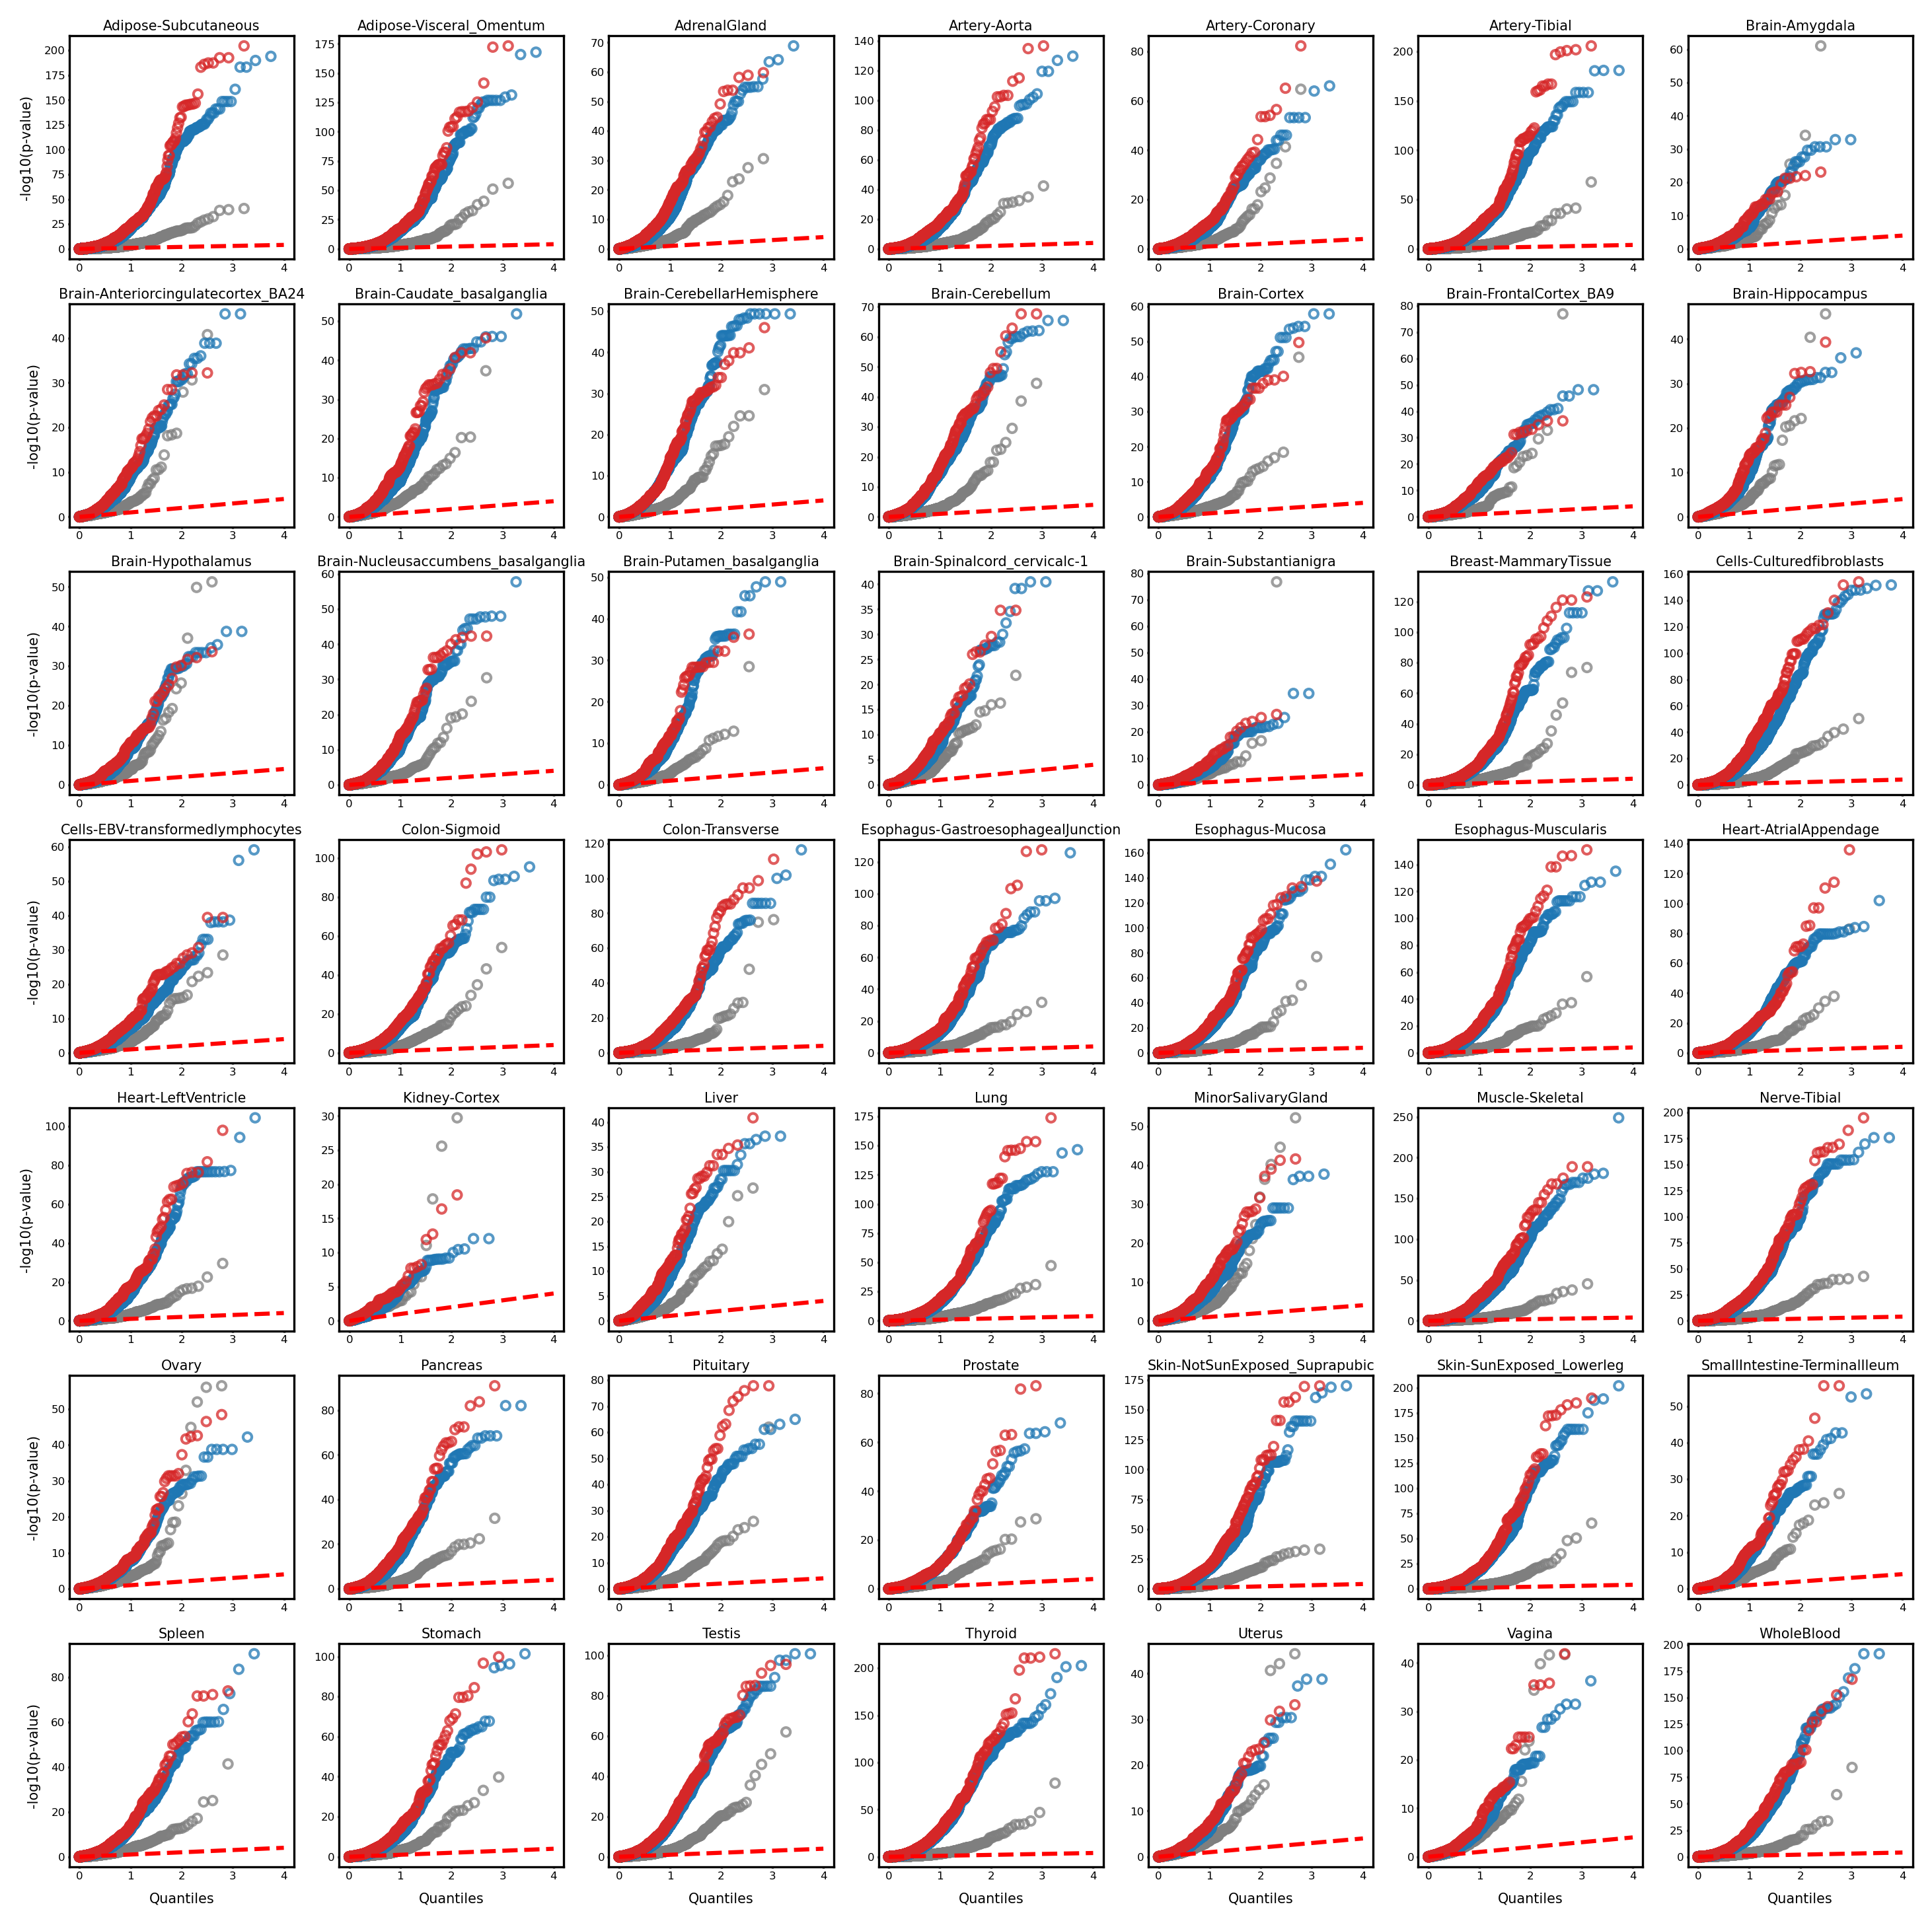

In [15]:
fig, ax = plt.subplots(7, 7, figsize=(12, 12), dpi=300)
i = 0
j = 0

tissue_rin_list = []
rho_rin_list = []
pval_rin_list = []

for tissue in sqtl_qq.keys():
    eqq = prepare_qq(sqtl_qq[tissue]['eQTLs'])
    pqq = prepare_qq(sqtl_qq[tissue]['ppsQTLs'])
    uqq = prepare_qq(sqtl_qq[tissue]['usQTLs'])
    
    ax[i,j].plot([0, 4], [0, 4], 'r--')
    
    ax[i, j].scatter(eqq[0], eqq[1], edgecolor = 'tab:gray', s=10, alpha=0.75, 
                     facecolor='none', rasterized=True)
    
    ax[i, j].scatter(pqq[0], pqq[1], edgecolor = 'tab:blue', s=10, alpha=0.75, 
                     facecolor='none', rasterized=True)
    
    ax[i, j].scatter(uqq[0], uqq[1], edgecolor = 'tab:red', s=10, alpha=0.75, 
                     facecolor='none', rasterized=True)
    
    if j == 0:
        ax[i,j].set_ylabel('-log10(p-value)', size=5)
    
    if (i == 6):
        ax[i,j].set_xlabel('Quantiles', size=5)
        
    
#     ax[i,j].set_yticks([])
    
    
    ax[i,j].tick_params(labelsize=4, length=0.5, pad=1)
    
    
#     ax[i,j].set_xticks([])
#     ax[i,j].set_yticks([])
    
    
    
    ax[i,j].set_title(tissue, size=5, pad=2)

    j += 1
    if j >= 7:
        j = 0
        i += 1
        
# ax[-1,-1].set_xticks([])
# ax[-1,-1].set_yticks([])
# ax[-1,-1].spines[['top', 'right', 'bottom', 'left']].set_visible(False)
# ax[-1,-1].set_facecolor('none')        
        
    
plt.savefig('../code/revision_plots/sup_fig_lambda.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/revision_plots/sup_fig_lambda.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/revision_plots/sup_fig_lambda.svg', dpi=300, bbox_inches='tight')    

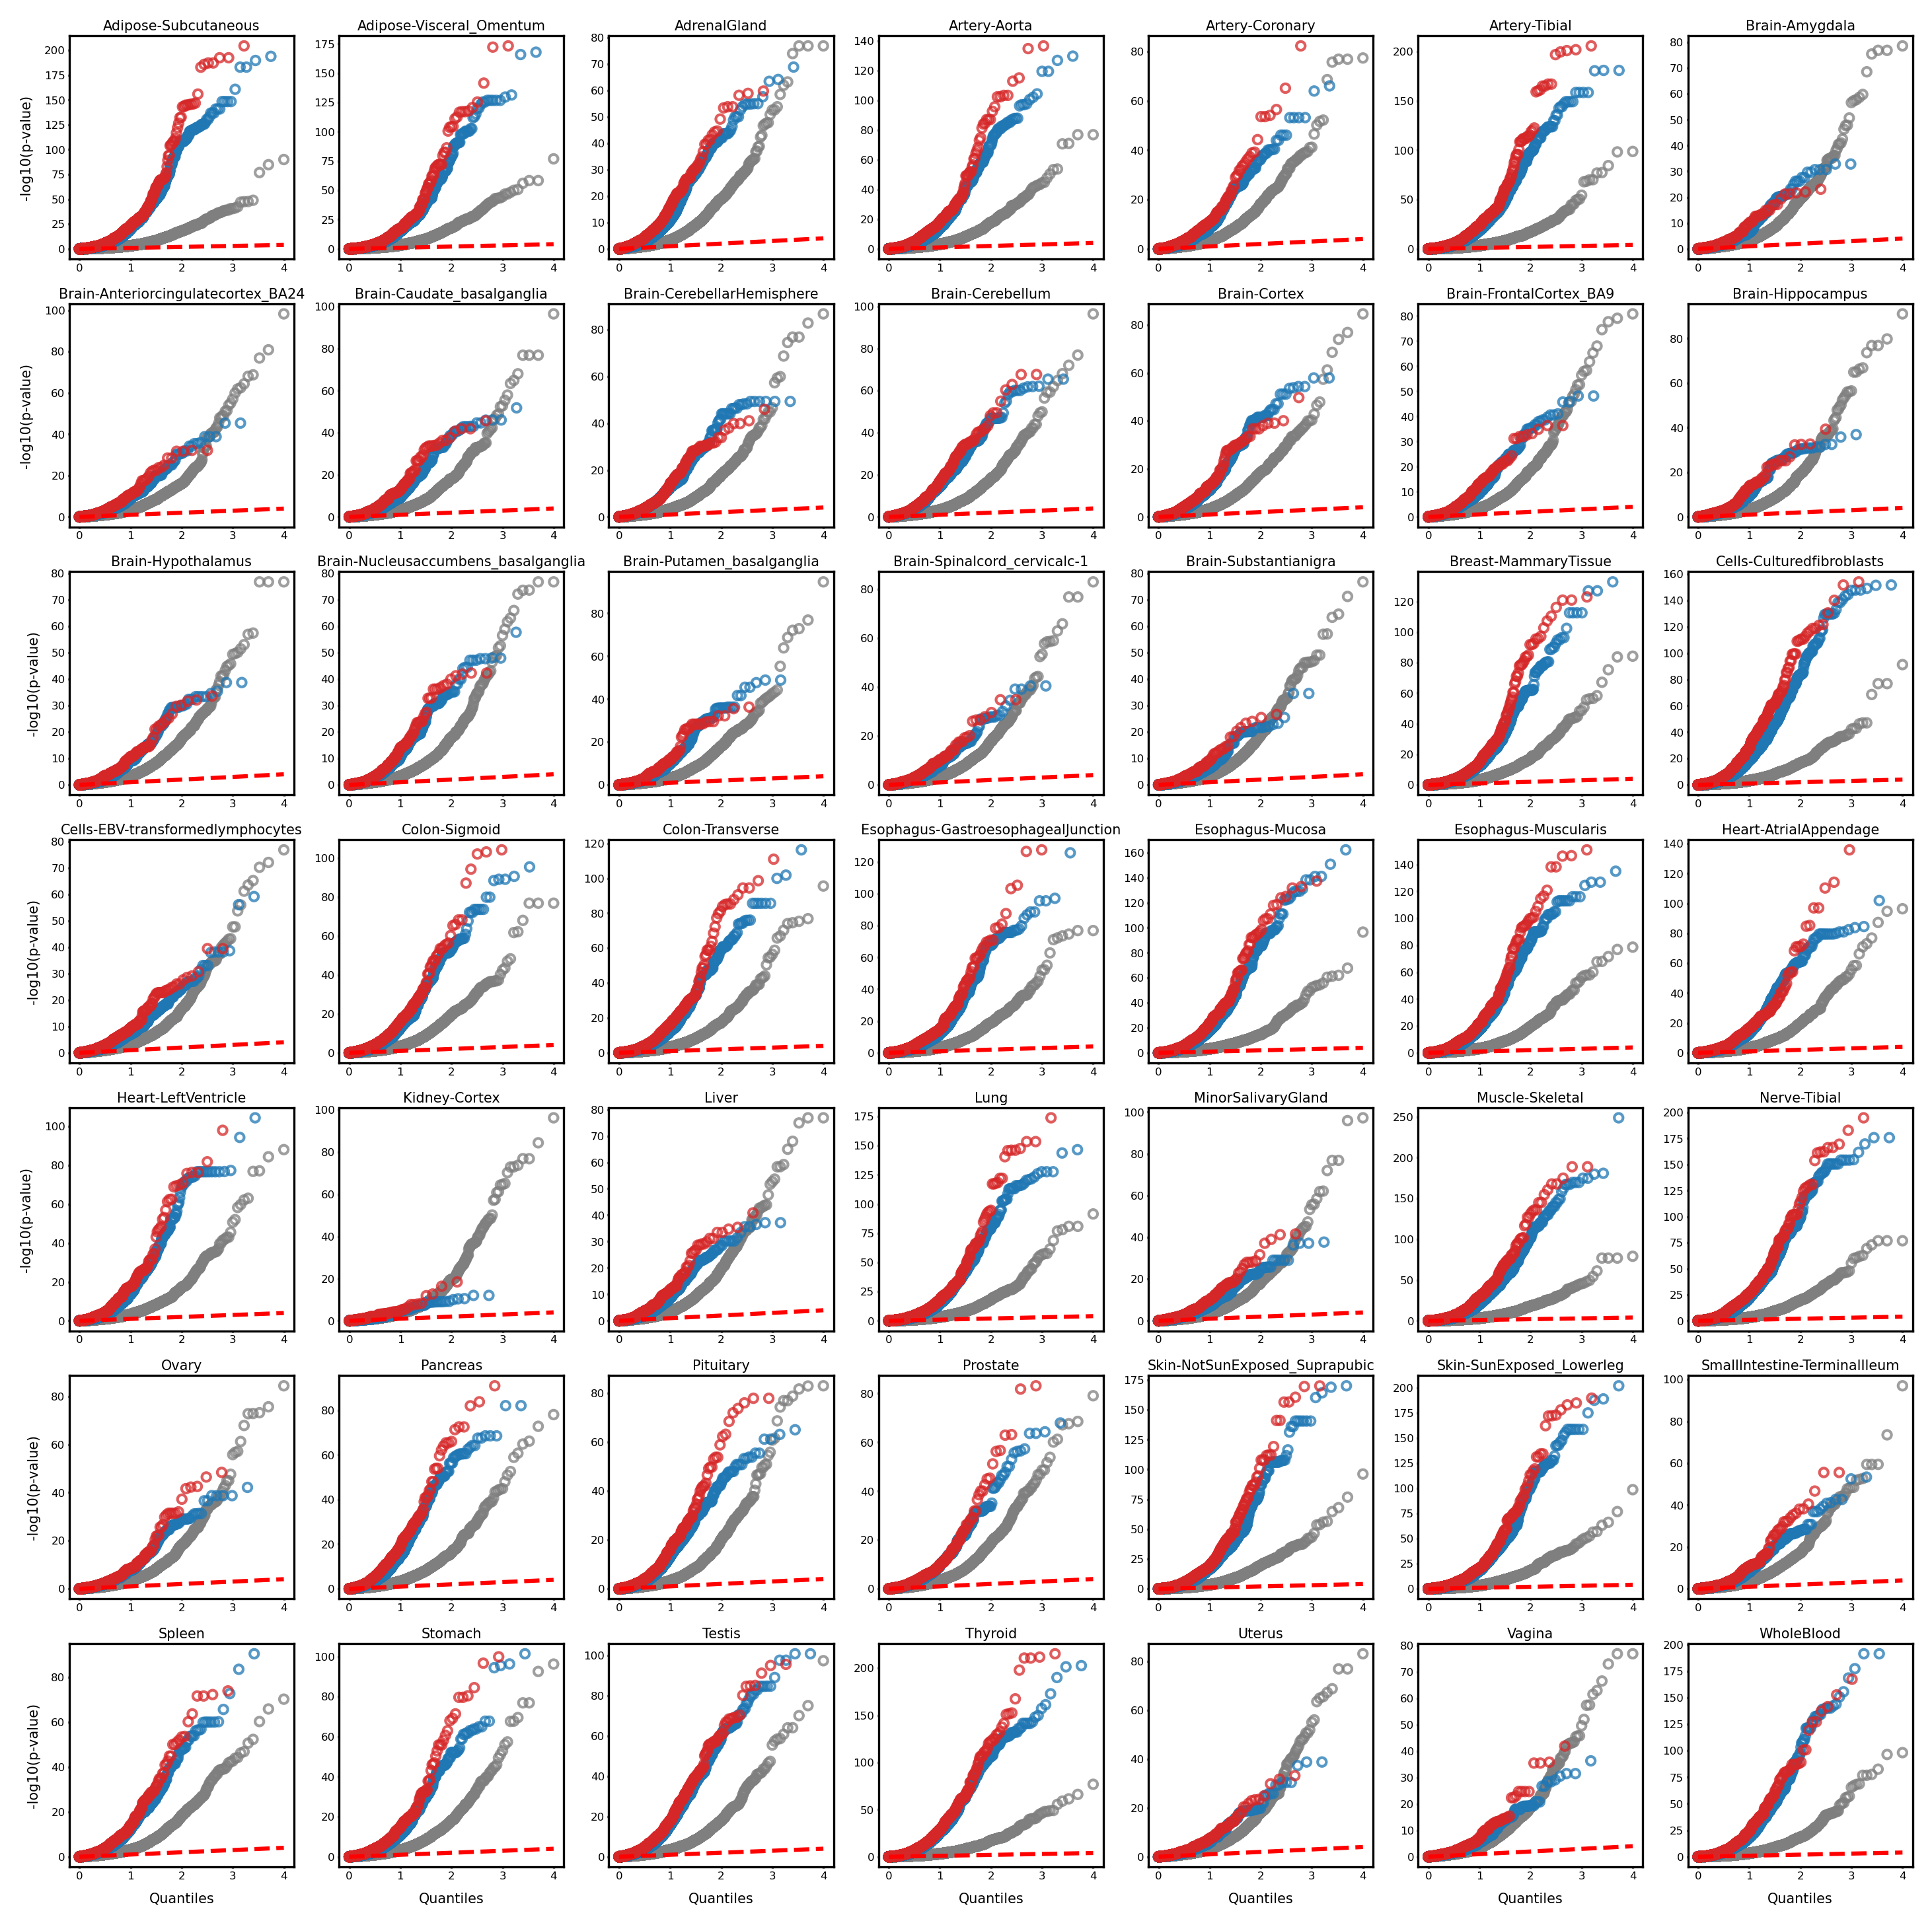

In [97]:
fig, ax = plt.subplots(7, 7, figsize=(12, 12), dpi=300)
i = 0
j = 0

tissue_rin_list = []
rho_rin_list = []
pval_rin_list = []

for tissue in sqtl_qq.keys():
    eqq = prepare_qq(sqtl_qq[tissue]['eQTLs'])
    pqq = prepare_qq(sqtl_qq[tissue]['ppsQTLs'])
    uqq = prepare_qq(sqtl_qq[tissue]['usQTLs'])
    
    ax[i,j].plot([0, 4], [0, 4], 'r--')
    
    ax[i, j].scatter(eqq[0], eqq[1], edgecolor = 'tab:gray', s=10, alpha=0.75, 
                     facecolor='none', rasterized=True)
    
    ax[i, j].scatter(pqq[0], pqq[1], edgecolor = 'tab:blue', s=10, alpha=0.75, 
                     facecolor='none', rasterized=True)
    
    ax[i, j].scatter(uqq[0], uqq[1], edgecolor = 'tab:red', s=10, alpha=0.75, 
                     facecolor='none', rasterized=True)
    
    if j == 0:
        ax[i,j].set_ylabel('-log10(p-value)', size=5)
    
    if (i == 6):
        ax[i,j].set_xlabel('Quantiles', size=5)
        
    
#     ax[i,j].set_yticks([])
    
    
    ax[i,j].tick_params(labelsize=4, length=0.5, pad=1)
    
    
#     ax[i,j].set_xticks([])
#     ax[i,j].set_yticks([])
    
    
    
    ax[i,j].set_title(tissue, size=5, pad=2)

    j += 1
    if j >= 7:
        j = 0
        i += 1
        
# ax[-1,-1].set_xticks([])
# ax[-1,-1].set_yticks([])
# ax[-1,-1].spines[['top', 'right', 'bottom', 'left']].set_visible(False)
# ax[-1,-1].set_facecolor('none')        
        
    
plt.savefig('../code/plots/sup_fig_lambda.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/sup_fig_lambda.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/sup_fig_lambda.svg', dpi=300, bbox_inches='tight')    

In [62]:
chroms = ['chr' + str(i) for i in range(1, 23)]
epvals = []

for chrom in chroms:
    nom_file = f'../code/results/eqtl/GTEx/Testis/cis_100000/nom/{chrom}.txt.gz'
    with gzip.open(nom_file, 'rb') as fh:
        fh.readline()
        for line in fh:
            row = line.decode().rstrip().split('\t')
            pval = float(row[11])
            epvals.append(pval)
            break
        

In [63]:
epvals

[0.416848,
 0.638271,
 0.43315,
 0.0304919,
 0.448646,
 0.149601,
 0.191346,
 0.636908,
 0.0135674,
 0.0274046,
 0.057634,
 0.554486,
 1.0,
 0.538535,
 0.333443,
 0.0921934,
 0.543845,
 0.336036,
 0.423304,
 0.607968,
 1.0,
 0.045506]

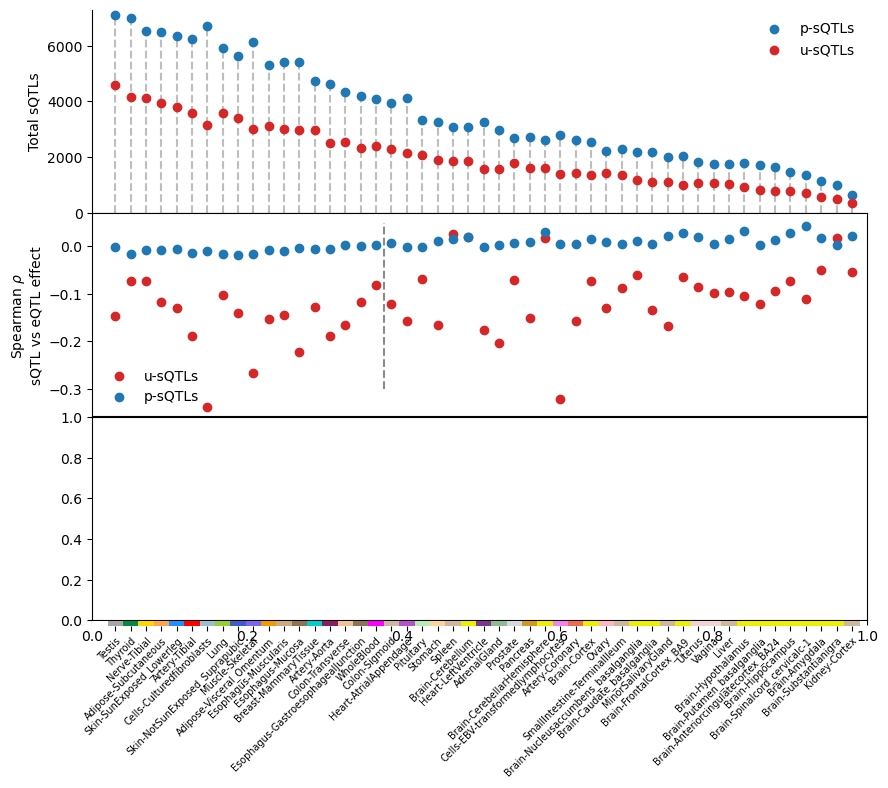

In [154]:
sorted_tissues = qtl_dataframe.sort_values(by="total", ascending=False).index

c_list = []
for tissue in sorted_tissues:
    c = '#' + gtex_colors[tissue]['tissue_color_hex']
    c_list.append(c)
    
fig, axes = plt.subplots(figsize = (10, 8), nrows=4, gridspec_kw={'height_ratios':[45, 45, 45, 1], 'hspace':0.005})
axes[0].scatter(
    np.arange(49)+0.5, np.array(qtl_dataframe.loc[sorted_tissues, 'PR']), 
    c= 'tab:blue', label='p-sQTLs', zorder=1# s=s
)

axes[0].scatter(np.arange(49)+0.5, 
    np.array(qtl_dataframe.loc[sorted_tissues, 'UP']),
    c= 'tab:red', label='u-sQTLs', zorder=2# s=s
)

for i in np.arange(49):
    axes[0].plot([i+0.5, i+0.5], [0, qtl_dataframe.loc[sorted_tissues[i], 'PR']], linestyle='--', c='tab:gray', zorder=0, alpha=0.5)



axes[0].set_xticks([])
axes[0].set_ylim([0,7300])
axes[0].set_xlim([-1,49.5])
axes[0].set_ylabel('Total sQTLs')
axes[0].legend(frameon=False)
axes[0].spines[['top', 'right']].set_visible(False)

###################################

axes[1].scatter(np.arange(49)+0.5,
    np.array(sqtl_stats.loc[sqtl_stats.sqtl_type == 'u_sqtl'].set_index('tissue').loc[sorted_tissues].spearman_rho),
     c= 'tab:red', label='u-sQTLs'# s=s
)

axes[1].scatter(np.arange(49)+0.5,
    np.array(sqtl_stats.loc[sqtl_stats.sqtl_type == 'pp_sqtl'].set_index('tissue').loc[sorted_tissues].spearman_rho),
     c='tab:blue', label='p-sQTLs' #s=s_
)

axes[1].plot([49-31, 49-31], [-0.3, 0.05], c='tab:gray', alpha=0.9, linestyle='--')


# axes[1].plot([0, 49], [0,0], c='tab:gray', alpha=0.9, linestyle='--')
# axes[1].text( 49-31+1, -0.3,'p-val = 0.05', c='black', alpha=0.9)

# plt.scatter(
#     np.array(sqtl_stats.loc[sqtl_stats.sqtl_type == 'p_sqtl'].set_index('tissue').loc[sorted_tissues].pearson_rho),
#     range(49)
# )

axes[1].set_xticks([])

axes[1].set_xlim([-1,49.5])
axes[1].set_ylabel(r'Spearman $\rho$' + '\nsQTL vs eQTL effect')
axes[1].legend(frameon=False)


###################################



axes[3].bar(np.arange(49)+0.5, [1]*49, width =1, color=c_list)



axes[3].set_xticks([])
axes[3].spines[['top', 'bottom', 'right', 'left']].set_visible(False)
axes[3].set_yticks([])

axes[3].set_xlim([-1,49.5])


axes[3].set_xticks(np.arange(49)+0.5, sorted_tissues, rotation=45, ha='right', rotation_mode='anchor', size=7)

In [ ]:
fig, axes = plt.subplots(figsize = (3.5, 6), ncols=2, gridspec_kw={'width_ratios':[1,15], 'wspace':0})
axes[1].scatter(
    np.array(sqtl_stats.loc[sqtl_stats.sqtl_type == 'u_sqtl'].set_index('tissue').loc[sorted_tissues].lambda_inflation),
    np.arange(49)+0.5, c= 'tab:red', label='u-sQTLs'# s=s
)

axes[1].scatter(
    np.array(sqtl_stats.loc[sqtl_stats.sqtl_type == 'pp_sqtl'].set_index('tissue').loc[sorted_tissues].lambda_inflation),
    np.arange(49)+0.5, c='tab:blue', label='p-sQTLs' #s=s_
)

axes[0].barh(range(49), [1]*49, height =1, color=c_list)

axes[1].plot([0,0], [0, 49], c='tab:gray', alpha=0.9, linestyle='--')

# plt.scatter(
#     np.array(sqtl_stats.loc[sqtl_stats.sqtl_type == 'p_sqtl'].set_index('tissue').loc[sorted_tissues].pearson_rho),
#     range(49)
# )

axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].spines[['top', 'bottom', 'right', 'left']].set_visible(False)
axes[1].set_yticks([])

axes[0].set_ylim([-1,49.5])
axes[1].set_ylim([-1,49.5])
axes[1].set_xlabel(r'Pearson $\rho$' + '\nsQTL vs eQTL effect')
axes[0].set_ylabel('Tissues (ranked by significance)')
axes[1].legend(frameon=False)

In [84]:
sqtl_slopes = []
eqtl_slopes = []
eqtl_pvals = []

perm_select = perm_counts.loc[(perm_counts.ctype == 'PR,UP') & (perm_counts.itype == 'UP') & (perm_counts.q <= 1e-2) & (perm_counts.cluster_psi >= 0.1)]
# idx = perm_counts.loc[(perm_counts.ctype == 'PR,UP') & (perm_counts.itype == 'UP') & (perm_counts.q <= 1e-2)].groupby('gene_id').median_counts.idxmax()
# perm_select = perm_counts.loc[idx]

for idx, row in perm_select.iterrows():
    try:
        eqtl_df = get_expression_effect('Testis', row)
        if eqtl_df.shape[0] > 0:
            eqtl_effect = eqtl_df.iloc[0].slope
            sqtl_slopes.append(row.slope)
            eqtl_slopes.append(float(eqtl_effect))
            eqtl_pvals.append(float(eqtl_df.iloc[0].nom_pval))
    except:
        continue
        

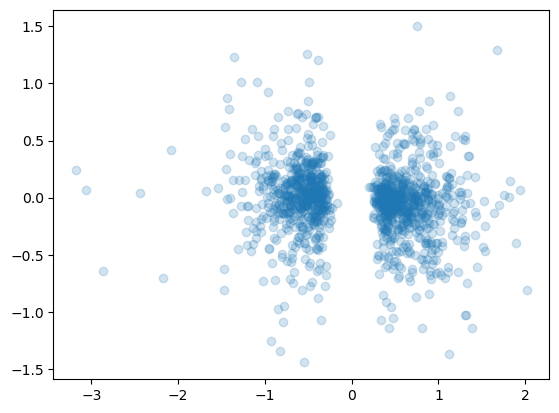

In [85]:
plt.scatter(sqtl_slopes, eqtl_slopes, alpha=0.2)

In [87]:
pearsonr(sqtl_slopes, eqtl_slopes)

PearsonRResult(statistic=np.float64(-0.12798196721218055), pvalue=np.float64(5.009380927191734e-06))

In [68]:
get_expression_effect('Liver', perm.loc[(perm.ctype == 'PR,UP') & (perm.itype == 'UP') & (perm.q <= 1e-2)].iloc[0]).iloc[0]

#phe_id             ENSG00000188976
phe_chr                        chr1
phe_from                     944203
phe_to                       959309
phe_strd                          -
n_var_in_cis                    592
dist_phe_var                  -2875
var_id          chr1_962184_T_C_b38
var_chr                        chr1
var_from                     962184
var_to                       962184
nom_pval                 0.00125833
r_squared                 0.0493607
slope                     -0.293436
best_hit                          0
Name: record5, dtype: object

In [69]:
float(eqtl_df.iloc[0].slope)/float(eqtl_df.iloc[0].r_squared)

-1.8495596450689622

In [54]:
tissue = 'Testis'
chrom = 'chr22'
run_tabix_on_nom(f'../code/results/eqtl/GTEx/{tissue}/cis_100000/nom/{chrom}.txt.gz', 'chr22:50722852:50722853', transform_to_df = True)

,#phe_id,phe_chr,phe_from,phe_to,phe_strd,n_var_in_cis,dist_phe_var,var_id,var_chr,var_from,var_to,nom_pval,r_squared,slope,best_hit
record0,ENSG00000079974.17,chr22,50767501,50783663,-,293,44648,chr22_50722853_C_A_b38,chr22,50722853,50722853,0.803448,0.000193862,-0.0241313,0
record1,ENSG00000100299.18,chr22,50622754,50628173,-,599,-94680,chr22_50722853_C_A_b38,chr22,50722853,50722853,0.0738625,0.00995023,0.179448,0
record2,ENSG00000251322.9,chr22,50674415,50733298,+,547,0,chr22_50722853_C_A_b38,chr22,50722853,50722853,0.887291,6.28717e-05,-0.0134714,0


In [39]:
perm.loc[(perm.ctype == 'PR,UP')].groupby('cluster').q.min()

cluster
chr10:clu_16631_+    0.995900
chr10:clu_16637_+    0.968890
chr10:clu_16639_+    0.972450
chr10:clu_16648_+    0.940910
chr10:clu_16653_+    0.976530
                       ...   
chr9:clu_16583_-     0.929580
chr9:clu_16595_-     0.651060
chr9:clu_16599_-     0.999560
chr9:clu_16601_-     0.011651
chr9:clu_16602_-     0.432950
Name: q, Length: 5785, dtype: float64

In [33]:
p_lambda([0.1, 0.00003, 1e-20, 0.5, 0.003, 0.0005, 1e-9])

np.float64(26.631556698226348)

In [32]:
p_lambda([0.1, 0.00003, 1e-20, 0.5, 0.003, 0.9, 0.0005, 1e-9])

np.float64(22.99566761047164)

In [40]:
p_lambda([0.1, 0.00003, 1e-20, 0.5, 0.003, 1e-90, 0.0005, 1e-9])

np.float64(32.45891616954008)

In [110]:
p_lambda([0.1, 0.00003, 1e-20, 0.5, 0.003, 1e-90, 0.0005, 1e-9], q=0.9)

np.float64(67.7913685882436)

In [41]:
p_lambda(eqtl_pvals)

np.float64(19.992119678650777)

In [106]:
p_lambda(eqtl_pvals)

NameError: name 'eqtl_pvals' is not defined

In [2]:
def aoe2_build_time(t, v):
    time_to_build = (3*t)/(2+v)
    return time_to_build

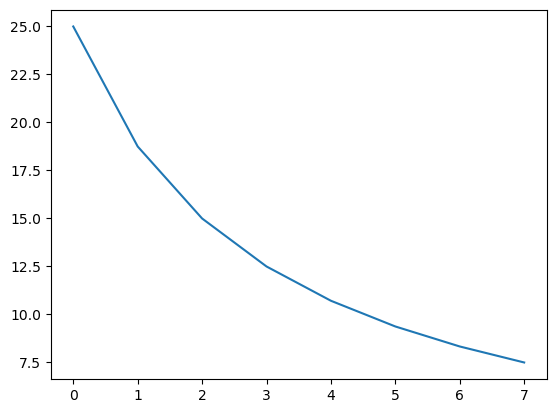

In [8]:
plt.plot(aoe2_build_time(25, np.arange(1, 9)))

In [31]:
import numpy as np
from scipy.stats import chi2

def p_lambda(p_values, df=1, q=0.5):
    """
    Calculate the lambda inflation factor from a distribution of p-values.

    Parameters:
    - p_values: array-like, list or numpy array of p-values.
    - df: int, degrees of freedom for the chi-squared test (default is 1).

    Returns:
    - lambda_gc: float, the genomic control inflation factor.
    """
    if len(p_values) == 0:
        raise ValueError("The p-values list cannot be empty.")
    
    # Filter out invalid p-values
    p_values = np.asarray(p_values)
    if np.any((p_values < 0) | (p_values > 1)):
        raise ValueError("All p-values must be between 0 and 1.")
    
    # Convert p-values to chi-squared statistics
    chi_squared_stats = chi2.isf(p_values, df)
    
    # Calculate the observed median chi-squared statistic
    median_observed = np.quantile(chi_squared_stats, q)#np.median(chi_squared_stats)
    
    # Calculate the expected median chi-squared statistic under the null hypothesis
    median_expected = chi2.ppf(q, df)
    
    # Calculate lambda inflation factor
    lambda_gc = median_observed / median_expected
    
    return lambda_gc

# Example usage
p_values = [0.05, 0.01, 0.02, 0.03, 0.1, 0.2]
lambda_value = p_lambda(p_values)
print(f"Lambda Inflation Factor: {lambda_value:.3f}")


Lambda Inflation Factor: 9.398
